In [106]:
%matplotlib inline

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
import lightkurve
import altaipony
import pandas as pd

print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Astropy:", astropy.__version__)
print("Lightkurve:", lightkurve.__version__)
print("AltaiPony:", altaipony.__version__)

NumPy: 2.5.3
Matplotlib: 3.11.1
Astropy: 8.0.1
Lightkurve: 2.6.0
AltaiPony: 2.1.2.


## Downloading Data

In [108]:
import lightkurve as lk
target_name="EV Lac"
search=lk.search_lightcurve(
    target_name,
    mission="TESS"
)
print(search)

SearchResult containing 24 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 16 2019      SPOC     120   154101678      0.0
  1 TESS Sector 56 2022      SPOC      20   154101678      0.0
  2 TESS Sector 57 2022      SPOC      20   154101678      0.0
  3 TESS Sector 56 2022      SPOC     120   154101678      0.0
  4 TESS Sector 57 2022      SPOC     120   154101678      0.0
  5 TESS Sector 83 2024      SPOC      20   154101678      0.0
  6 TESS Sector 84 2024      SPOC      20   154101678      0.0
  7 TESS Sector 83 2024      SPOC     120   154101678      0.0
  8 TESS Sector 84 2024      SPOC     120   154101678      0.0
  9 TESS Sector 16 2019 TESS-SPOC    1800   154101678      0.0
 10 TESS Sector 56 2022 TESS-SPOC     200   154101678      0.0
 11 TESS Sector 57 2022 TESS-SPOC     200   154101678      0.0
 12 TESS Sec

In [109]:
lc=search[1].download()
print(lc)

0% (284/117799) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).
0% (284/117799) of the cadences will be ignored due to the quality mask (quality_bitmask=17087).


       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
 2825.260771600005  1.0971659e+05 ... -2.4827465e-02 -1.6516671e-02
2825.2610030881315  1.0999902e+05 ...  3.4841169e-03  6.0533460e-02
 2825.261234576491  1.1001529e+05 ...  2.3123783e-03  3.5794534e-02
2825.2614660646177  1.0997265e+05 ...  7.3794788e-03  3.1121613e-02
2825.2616975527435  1.0993330e+05 ... -4.5873439e-03 -6.1602956e-03
 2825.261929041103  1.0979262e+05 ... -1.6855052e-03  2.6946681e-02
2825.2621605292297  1.0978695e+05 ... -9.1639012e-03  6.9694452e-02
2825.2623920175893  1.1021774e+05 ... -9.0896869e-03  1.3689788e-02
 2825.262623505715  1.0996592e+05 ... -3.1228382e-03  1.5772749e-02
               ...            ... ...            ...            ...
 2853.141224979235  1.1142609e+05 ... -4.3032855e-02 -3.9645102e-02
2853.1414564606093  1.1126338e+05 ... -4.0872552

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

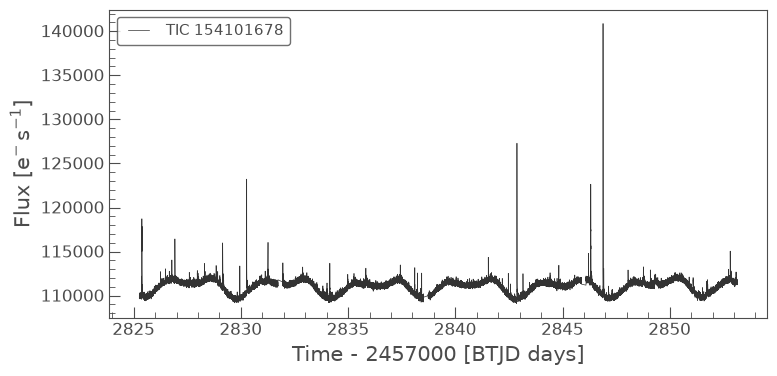

In [210]:
lc.plot()

In [111]:
print(lc.colnames)
print(lc.meta)

['time', 'flux', 'flux_err', 'timecorr', 'cadenceno', 'centroid_col', 'centroid_row', 'sap_flux', 'sap_flux_err', 'sap_bkg', 'sap_bkg_err', 'pdcsap_flux', 'pdcsap_flux_err', 'quality', 'psf_centr1', 'psf_centr1_err', 'psf_centr2', 'psf_centr2_err', 'mom_centr1', 'mom_centr1_err', 'mom_centr2', 'mom_centr2_err', 'pos_corr1', 'pos_corr2']
{'INHERIT': True, 'EXTNAME': 'PRIMARY', 'EXTVER': 1, 'SIMDATA': False, 'TELESCOP': 'TESS', 'INSTRUME': 'TESS Photometer', 'OBJECT': 'TIC 154101678', 'TICID': 154101678, 'RADESYS': 'ICRS', 'RA_OBJ': 341.707213223732, 'DEC_OBJ': 44.3339922849981, 'EQUINOX': 2000.0, 'EXPOSURE': 27.604169686596, 'TIMEREF': 'SOLARSYSTEM', 'TASSIGN': 'SPACECRAFT', 'TIMESYS': 'TDB', 'BJDREFI': 2457000, 'BJDREFF': 0.0, 'TIMEUNIT': 'd', 'TELAPSE': 27.882999683431, 'LIVETIME': 27.604169686596318, 'TSTART': 2825.260424483672, 'TSTOP': 2853.143423935621, 'DATE-OBS': '2022-09-02T18:13:51.491', 'DATE-END': '2022-09-30T15:25:22.644', 'DEADC': 0.99, 'TIMEPIXR': 0.5, 'TIERRELA': 1.16e-0

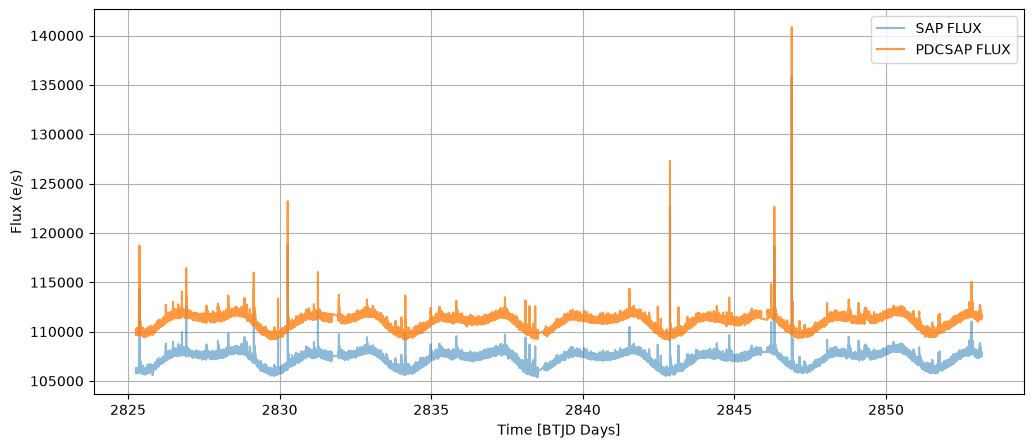

In [112]:
time=lc.time.value
plt.figure(figsize=(12, 5))

plt.plot(time, lc.sap_flux,label="SAP FLUX",alpha=0.5)
plt.plot(time, lc.pdcsap_flux,label="PDCSAP FLUX",alpha=0.8)

plt.xlabel("Time [BTJD Days]")
plt.ylabel("Flux (e/s)")
plt.grid(True)
plt.legend()
plt.show()

## AltaiPony

In [113]:
import sys
import numpy
import altaipony

print("Python:", sys.executable)
print("Numpy:", numpy.__version__)
print("AltaiPony:", altaipony.__version__)

Python: /Users/alanjohn/flare_project/bin/python
Numpy: 2.5.3
AltaiPony: 2.1.2.


In [114]:
from altaipony.flarelc import FlareLightCurve
flare_lc= FlareLightCurve(
    time= lc.time,
    flux= lc.pdcsap_flux,
    flux_err= lc.pdcsap_flux_err
    )
print(flare_lc)

       time             flux         flux_err   
                    electron / s   electron / s 
------------------ -------------- --------------
 2825.260771600005  1.0971659e+05  8.2818680e+01
2825.2610030881315  1.0999902e+05  8.2976456e+01
 2825.261234576491  1.1001529e+05  8.2961807e+01
2825.2614660646177  1.0997265e+05  8.2961601e+01
2825.2616975527435  1.0993330e+05  8.2941856e+01
 2825.261929041103  1.0979262e+05  8.2916656e+01
2825.2621605292297  1.0978695e+05  8.2895958e+01
2825.2623920175893  1.1021774e+05  8.2965042e+01
 2825.262623505715  1.0996592e+05  8.2942085e+01
               ...            ...            ...
 2853.141224979235  1.1142609e+05  8.3537506e+01
2853.1414564606093  1.1126338e+05  8.3499657e+01
 2853.141687941984  1.1168495e+05  8.3611725e+01
2853.1419194233586  1.1157051e+05  8.3549431e+01
2853.1421509042675  1.1146616e+05  8.3570000e+01
 2853.142382385642  1.1147309e+05  8.3623657e+01
2853.1426138670167  1.1147755e+05  8.3550751e+01
2853.1428453483913  

In [115]:
print(flare_lc.colnames)
print(flare_lc.meta)

['time', 'flux', 'flux_err']
{}


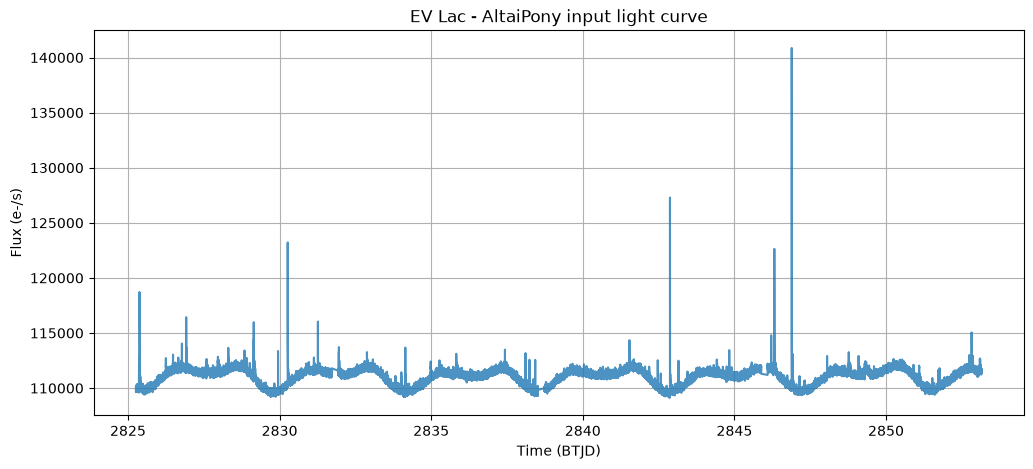

In [116]:
plt.figure(figsize=(12,5))
plt.plot(flare_lc.time.value,flare_lc.flux,alpha=0.8)
plt.xlabel("Time (BTJD)")
plt.ylabel("Flux (e-/s)")
plt.title(f"{target_name} - AltaiPony input light curve")
plt.grid(True)
plt.show()


## Detrending

In [117]:
detrended_lc= flare_lc.detrend("savgol")

In [118]:
print(detrended_lc)

       time             flux      ... flux_model detrended_flux_err
                    electron / s  ...               electron / s   
------------------ -------------- ... ---------- ------------------
 2825.260771600005  1.0971659e+05 ...        nan      8.2818680e+01
2825.2610030881315  1.0999902e+05 ...        nan      8.2976456e+01
 2825.261234576491  1.1001529e+05 ...        nan      8.2961807e+01
2825.2614660646177  1.0997265e+05 ...        nan      8.2961601e+01
2825.2616975527435  1.0993330e+05 ...        nan      8.2941856e+01
 2825.261929041103  1.0979262e+05 ...        nan      8.2916656e+01
2825.2621605292297  1.0978695e+05 ...        nan      8.2895958e+01
2825.2623920175893  1.1021774e+05 ...        nan      8.2965042e+01
 2825.262623505715  1.0996592e+05 ...        nan      8.2942085e+01
               ...            ... ...        ...                ...
 2853.141224979235  1.1142609e+05 ...  111495.53      8.3537506e+01
2853.1414564606093  1.1126338e+05 ...  111491.98

In [119]:
print(detrended_lc.colnames)

['time', 'flux', 'flux_err', 'detrended_flux', 'flux_model', 'detrended_flux_err']


In [120]:
normalised_flux=(detrended_lc.detrended_flux/ np.nanmean(detrended_lc.detrended_flux))

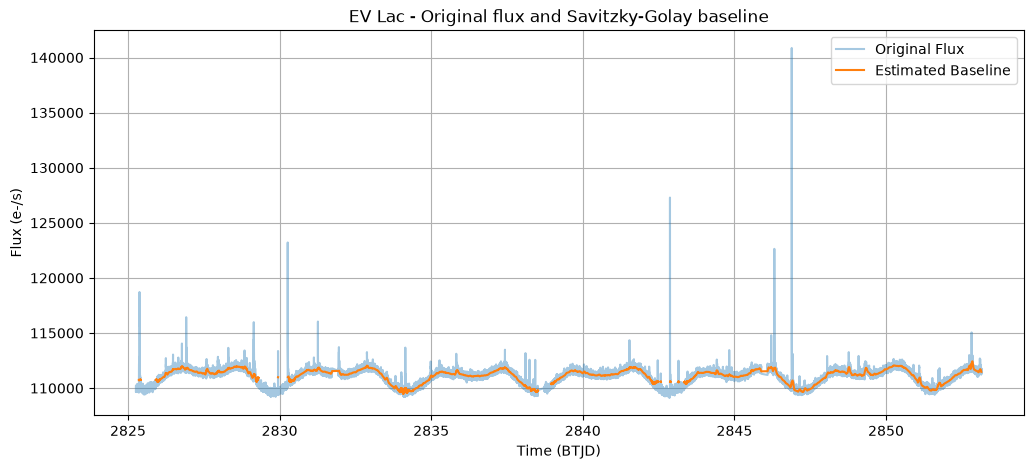

In [121]:
plt.figure(figsize=(12,5))
plt.plot(flare_lc.time.value, flare_lc.flux, alpha=0.4, label="Original Flux")
plt.plot(detrended_lc.time.value, detrended_lc.flux_model, label="Estimated Baseline")
plt.xlabel("Time (BTJD)")
plt.ylabel("Flux (e-/s)")
plt.title(f"{target_name} - Original flux and Savitzky-Golay baseline")
plt.legend()
plt.grid(True)
plt.show()


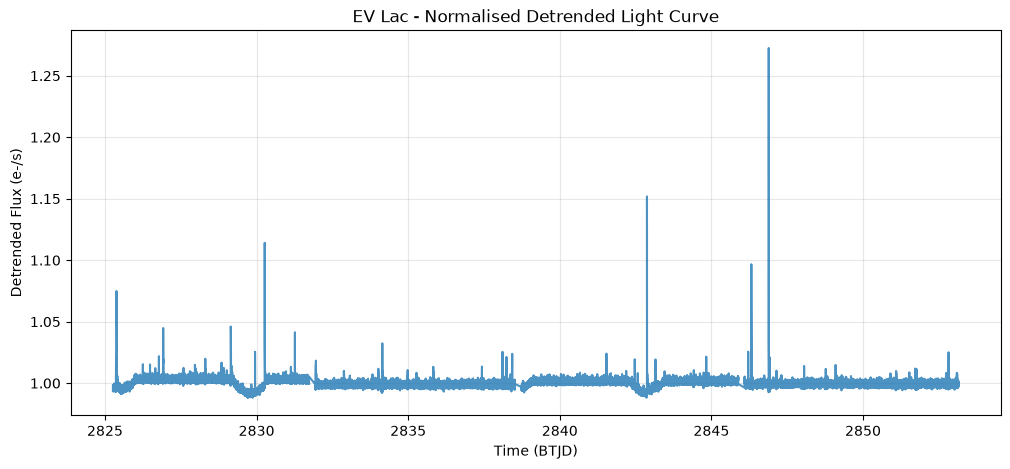

In [122]:
plt.figure(figsize=(12,5))
plt.plot(detrended_lc.time.value,normalised_flux, alpha=0.8)
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux (e-/s)")
plt.title(f"{target_name} - Normalised Detrended Light Curve")
plt.grid(True, alpha =0.3)
plt.show()


## Finding Flares

In [123]:
flares1=detrended_lc.find_flares()

Found 37 candidate(s) in the (0,27896) gap.
Found 32 candidate(s) in the (27896,56241) gap.
Found 32 candidate(s) in the (56241,87092) gap.
Found 41 candidate(s) in the (87092,117515) gap.
/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)


In [124]:
print(flares1.colnames)

['time', 'flux', 'flux_err', 'detrended_flux', 'flux_model', 'detrended_flux_err', 'it_med', 'cadenceno']


In [125]:
print(flares1)

       time             flux         flux_err    ...   it_med  cadenceno
                    electron / s   electron / s  ...                    
------------------ -------------- -------------- ... --------- ---------
 2825.260771600005  1.0971659e+05  8.2818680e+01 ... 111441.34       nan
2825.2610030881315  1.0999902e+05  8.2976456e+01 ... 111441.34       nan
 2825.261234576491  1.1001529e+05  8.2961807e+01 ... 111441.34       nan
2825.2614660646177  1.0997265e+05  8.2961601e+01 ... 111441.34       nan
2825.2616975527435  1.0993330e+05  8.2941856e+01 ... 111441.34       nan
 2825.261929041103  1.0979262e+05  8.2916656e+01 ... 111441.34       nan
2825.2621605292297  1.0978695e+05  8.2895958e+01 ... 111441.34       nan
2825.2623920175893  1.1021774e+05  8.2965042e+01 ... 111441.34       nan
 2825.262623505715  1.0996592e+05  8.2942085e+01 ... 111441.34       nan
               ...            ...            ... ...       ...       ...
 2853.141224979235  1.1142609e+05  8.3537506e+01 ..

In [126]:
print(type(flares1))

<class 'altaipony.flarelc.FlareLightCurve'>


In [127]:
print(flares1.meta)

{'gaps': [(np.int64(0), np.int64(27896)), (np.int64(27896), np.int64(56241)), (np.int64(56241), np.int64(87092)), (np.int64(87092), np.int64(117515))], 'flares':      istart   istop  cstart  cstop       tstart        tstop  \
0       446     449     NaN    NaN  2825.364015  2825.364710   
1       505     594     NaN    NaN  2825.377673  2825.398507   
2      4256    4285     NaN    NaN  2826.248531  2826.255475   
3      4640    4643     NaN    NaN  2826.337654  2826.338348   
4      5277    5289     NaN    NaN  2826.485111  2826.487889   
..      ...     ...     ...    ...          ...          ...   
137  115782  115800     NaN    NaN  2852.741920  2852.746086   
138  116125  116133     NaN    NaN  2852.821318  2852.823170   
139  116190  116202     NaN    NaN  2852.836364  2852.839142   
140  117297  117319     NaN    NaN  2853.092845  2853.097938   
141  117346  117350     NaN    NaN  2853.104188  2853.105345   

                 ed_rec            ed_rec_err      ampl_rec       dur

In [128]:
print(flares1.it_med[:20])

[111441.34 111441.34 111441.34 111441.34 111441.34 111441.34 111441.34
 111441.34 111441.34 111441.34 111441.34 111441.34 111441.34 111441.34
 111441.34 111441.34 111441.34 111441.34 111441.34 111441.34]


In [129]:
flare_table= flares1.meta["flares"]
print(flare_table.columns)
print("Number of flares:", len(flare_table))

Index(['istart', 'istop', 'cstart', 'cstop', 'tstart', 'tstop', 'ed_rec',
       'ed_rec_err', 'ampl_rec', 'dur', 'total_n_valid_data_points'],
      dtype='object')
Number of flares: 142


In [130]:
print(flare_table[["tstart", "tstop", "ed_rec","ampl_rec", "dur"]].head(10))

        tstart        tstop               ed_rec      ampl_rec       dur
0  2825.364015  2825.364710   0.5447928231015062   0.013310432  0.000694
1  2825.377673  2825.398507     50.6078471678308    0.07175124  0.020834
2  2826.248531  2826.255475    3.707692676140379   0.012473226  0.006945
3  2826.337654  2826.338348   0.2625320898545347   0.005005002  0.000694
4  2826.485111  2826.487889   1.6272931577259335   0.012259126  0.002778
5  2826.549696  2826.550391  0.18192300067941147  0.0034415722  0.000694
6  2826.658727  2826.660810   0.9619799273191454   0.009282589  0.002083
7  2826.759887  2826.761507    0.605301039512554   0.005559802  0.001620
8  2826.778869  2826.783962   2.5967348372781487    0.01895237  0.005093
9  2826.919845  2826.931419   13.348731530201764    0.04178524  0.011574


Start: 2825.364015328676
Stop: 2825.3647097932885
Amplitude: 0.013310432
Duration: 1.000029041970265


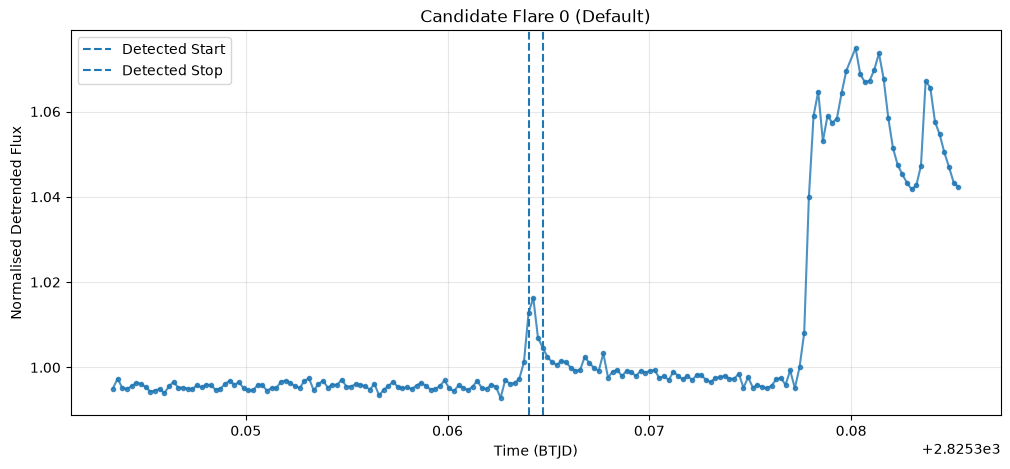

Start: 2825.377673129541
Stop: 2825.3985070620975
Amplitude: 0.07175124
Duration: 30.0008628811338


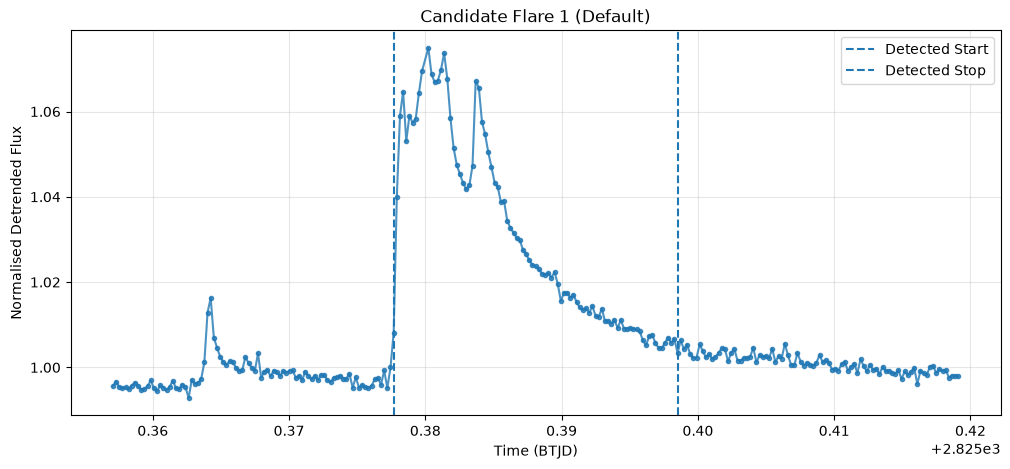

Start: 2826.549696212224
Stop: 2826.5503906752065
Amplitude: 0.0034415722
Duration: 1.000026695037377


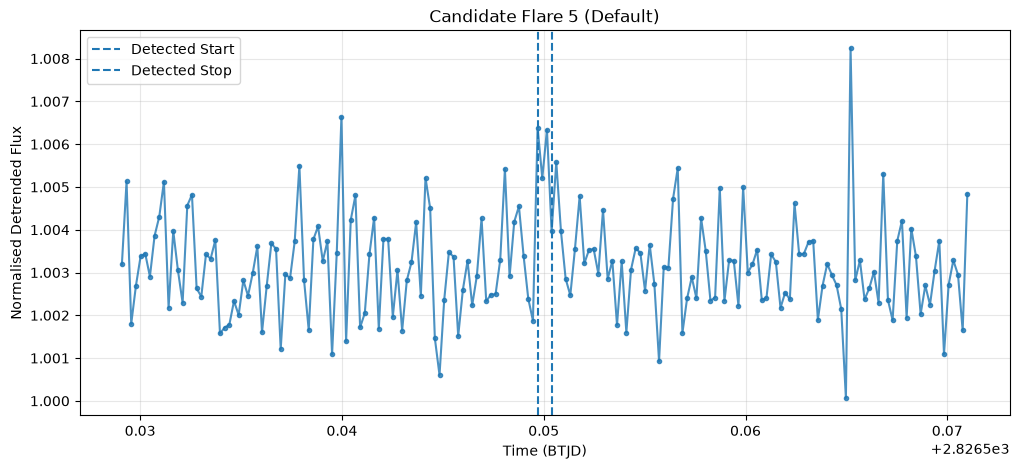

In [131]:
for x in (0,1,5):
    individual_flare=flare_table.iloc[x]
    t_start=individual_flare["tstart"]
    t_stop=individual_flare["tstop"]

    print("Start:",t_start)
    print("Stop:",t_stop)
    print("Amplitude:",individual_flare["ampl_rec"])
    print("Duration:",individual_flare["dur"]*24*60)

    window=30 #in min
    window=window/(24*60)

    mask=((detrended_lc.time.value>= t_start-window) & (detrended_lc.time.value<= t_stop+window))

    plt.figure(figsize=(12,5))
    plt.plot(detrended_lc.time.value[mask], normalised_flux[mask], marker="o", markersize=3, alpha=0.8)
    plt.axvline(t_start,linestyle="--", label='Detected Start')
    plt.axvline(t_stop,linestyle="--", label='Detected Stop')
    plt.xlabel("Time (BTJD)")
    plt.ylabel("Normalised Detrended Flux")
    plt.title(f"Candidate Flare {x} (Default)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [132]:
quality= np.array(lc.quality)
print("Tolat Cadences:", len(quality))
print("Quality=0:",np.sum(quality==0))
print("Quality>0:",np.sum(quality>0))

Tolat Cadences: 117515
Quality=0: 113531
Quality>0: 3984


In [133]:
unique_quality, counts = np.unique(quality, return_counts=True)

for q, count in zip(unique_quality, counts):

    print(q, count)

0 113531
64 2131
1024 1821
1088 32


In [134]:
mask_64=(lc.quality & 64)>0
mask_1024=(lc.quality & 1024)>0

print("Flag 64:", np.sum(mask_64))
print("Flag 1024:", np.sum(mask_1024))
print("Both:", np.sum(mask_64 & mask_1024))

Flag 64: 2163
Flag 1024: 1853
Both: 32


In [135]:
# plt.figure(figsize=(12,5))
# plt.plot(lc.time.value, lc.pdcsap_flux,label="PDCSAP Flux" ,alpha=0.5)
# plt.scatter(lc.time.value[mask_64], lc.pdcsap_flux[mask_64],label="Flag 64: Aperture Cosmic Ray" ,s=5, alpha=0.6)
# plt.scatter(lc.time.value[mask_1024], lc.pdcsap_flux[mask_1024],label="Flag 1024: Collateral Cosmic Ray" ,s=5,alpha=0.8)
# plt.xlabel("Time (BTJD)")
# plt.ylabel("PDCSAP Flux (e-/s)")
# plt.title(f"{target_name}- Quality Flags")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [136]:
flagged_candidates=[]
for i, flare in flare_table.iterrows():
    mask1=((lc.time.value >=flare["tstart"])&(lc.time.value <=flare["tstop"]))
    n_points=np.sum(mask1)
    n_flags=np.sum(lc.quality[mask1]!=0)
    flagged_candidates.append([i, n_points, n_flags])

flagged_candidates=np.array(flagged_candidates)

print("Total Number of points:", len(flagged_candidates))
print("Candidates with at least 1 flagged cadence:", np.sum(flagged_candidates[:,2]>0))
print("Candidate with no flagged cadence:", np.sum(flagged_candidates[:,2]==0))

Total Number of points: 142
Candidates with at least 1 flagged cadence: 61
Candidate with no flagged cadence: 81


In [137]:
for n in (0,1,5,49,57):
    individual_flare=flare_table.iloc[n]
    mask1=((lc.time.value >=individual_flare["tstart"])&(lc.time.value <=individual_flare["tstop"]))
    n_points=np.sum(mask1)
    n_flags=np.sum(lc.quality[mask1]!=0)
    print(f"Candidate: {n}      No: Points:{n_points}     No: Flaggs:{n_flags}")

Candidate: 0      No: Points:4     No: Flaggs:0
Candidate: 1      No: Points:90     No: Flaggs:1
Candidate: 5      No: Points:4     No: Flaggs:0
Candidate: 49      No: Points:5     No: Flaggs:0
Candidate: 57      No: Points:6     No: Flaggs:0


In [138]:
for n in (1,14):
    individual_flare=flare_table.iloc[n]
    mask1=((lc.time.value >=individual_flare["tstart"])&(lc.time.value <=individual_flare["tstop"]))
    flagged= mask1 & (lc.quality !=0)
    print(f"\nCandidate:{n}")
    print(f"Flagged points:")
    for t,f,q in zip(lc.time.value[flagged], lc.pdcsap_flux[flagged], lc.quality[flagged]):
        print(f"Time= {t:.9f} Flux= {f:.2f} Quality={q}")



Candidate:1
Flagged points:
Time= 2825.395960692 Flux= 111109.32 electron / s Quality=1024

Candidate:14
Flagged points:


Start: 2825.377673129541
Stop: 2825.3985070620975
Amplitude: 0.07175124
Duration: 30.0008628811338


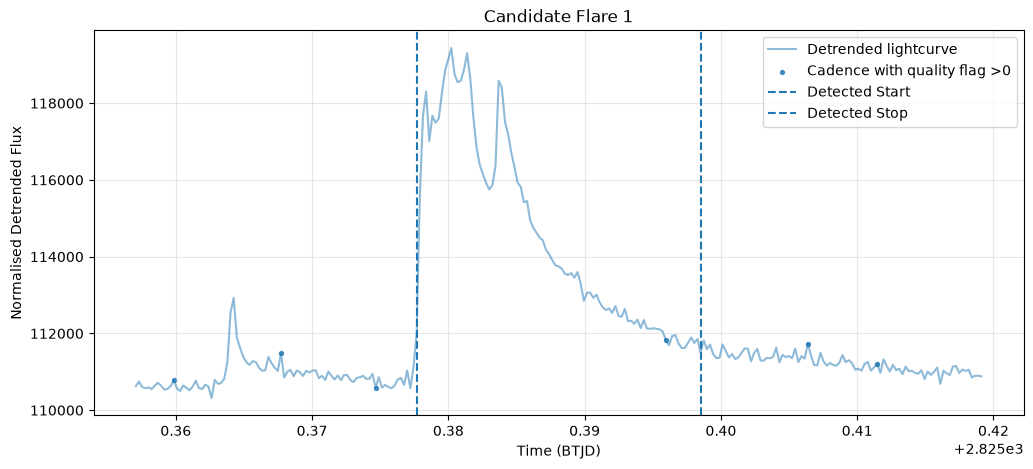

Start: 2853.092845395241
Stop: 2853.097937983153
Amplitude: 0.009133577
Duration: 7.333326592997764


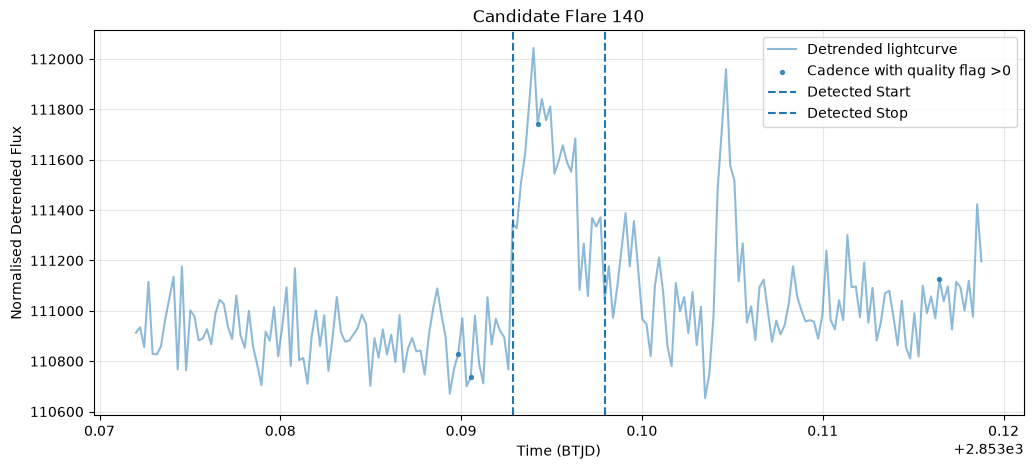

In [139]:
for n in (1,140):
    individual_flare=flare_table.iloc[n]

    window=30 #in min
    window=window/(24*60)

    t_start=individual_flare["tstart"]
    t_stop=individual_flare["tstop"]

    mask=((detrended_lc.time.value>= t_start-window) & (detrended_lc.time.value<= t_stop+window))
    flagged= mask & (lc.quality !=0)

    print("Start:",t_start)
    print("Stop:",t_stop)
    print("Amplitude:",individual_flare["ampl_rec"])
    print("Duration:",individual_flare["dur"]*24*60)

    plt.figure(figsize=(12,5))
    plt.plot(detrended_lc.time.value[mask], detrended_lc.detrended_flux[mask], label="Detrended lightcurve", alpha=0.5)
    plt.scatter(detrended_lc.time.value[flagged], detrended_lc.detrended_flux[flagged],label="Cadence with quality flag >0" ,s=8, alpha=0.8)
    plt.axvline(t_start,linestyle="--", label='Detected Start')
    plt.axvline(t_stop,linestyle="--", label='Detected Stop')
    plt.xlabel("Time (BTJD)")
    plt.ylabel("Normalised Detrended Flux")
    plt.title(f"Candidate Flare {n}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Quality flag == 0

In [140]:
quality_mask= (lc.quality)==0
clean_lc= lc[quality_mask]
#clean_lc= lc

print("Original Cadences= ",len(lc))
print("Clean Cadences= ", len(clean_lc))
print("Removed Cadences= ", len(lc)-len(clean_lc))
print("remaining flagged cadences= ", np.sum(clean_lc.quality !=0))

Original Cadences=  117515
Clean Cadences=  113531
Removed Cadences=  3984
remaining flagged cadences=  0


In [141]:
from altaipony.flarelc import FlareLightCurve
clean_flare_lc= FlareLightCurve(time=clean_lc.time, flux=clean_lc.pdcsap_flux, flux_err=clean_lc.pdcsap_flux_err)

print(clean_flare_lc.colnames)
print("Number of Cadences:", len(clean_flare_lc))

['time', 'flux', 'flux_err']
Number of Cadences: 113531


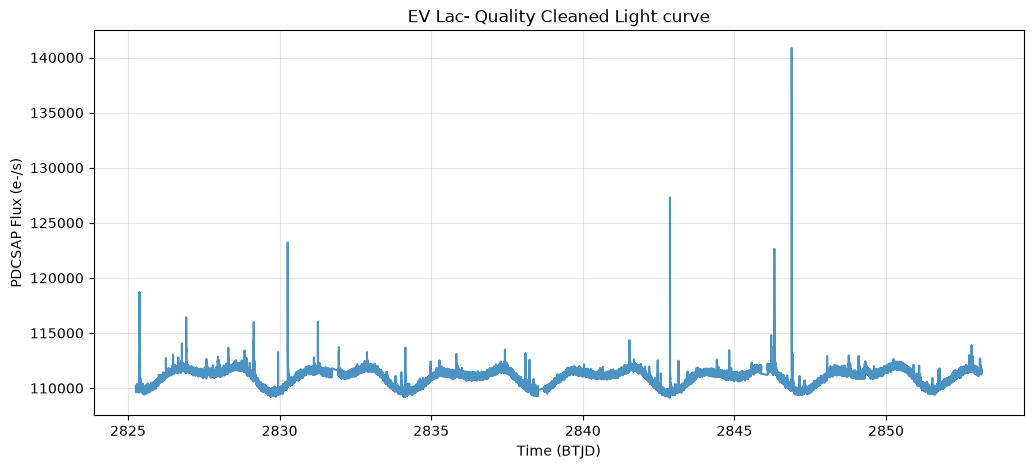

In [142]:
plt.figure(figsize=(12,5))
plt.plot(clean_flare_lc.time.value, clean_flare_lc.flux, alpha=0.8)
plt.ylabel("PDCSAP Flux (e-/s)")
plt.xlabel("Time (BTJD)")
plt.title(f"{target_name}- Quality Cleaned Light curve")
plt.grid(True,alpha=0.3)
plt.show()

In [143]:
clean_detrended_lc= clean_flare_lc.detrend("savgol")
print(clean_detrended_lc.colnames)

['time', 'flux', 'flux_err', 'detrended_flux', 'flux_model', 'detrended_flux_err']


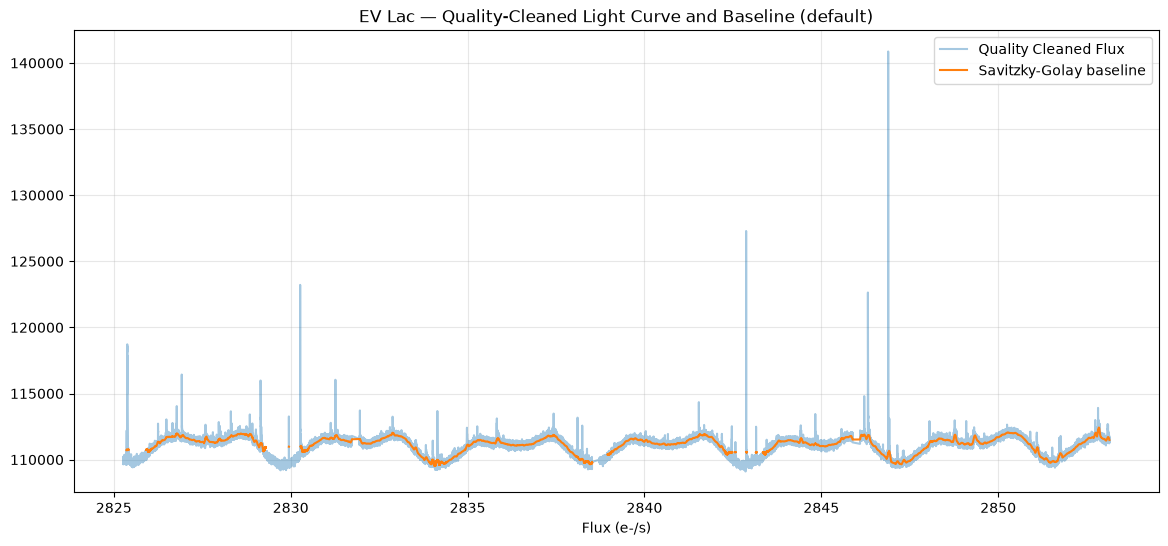

In [144]:
plt.figure(figsize=(14,6))
plt.plot(clean_flare_lc.time.value,clean_flare_lc.flux, alpha=0.4,label="Quality Cleaned Flux")
plt.plot(clean_detrended_lc.time.value,clean_detrended_lc.flux_model,alpha=1, label="Savitzky-Golay baseline")
plt.xlabel("Time (BTJD)")
plt.xlabel("Flux (e-/s)")
plt.title(f"{target_name} — Quality-Cleaned Light Curve and Baseline (default)")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

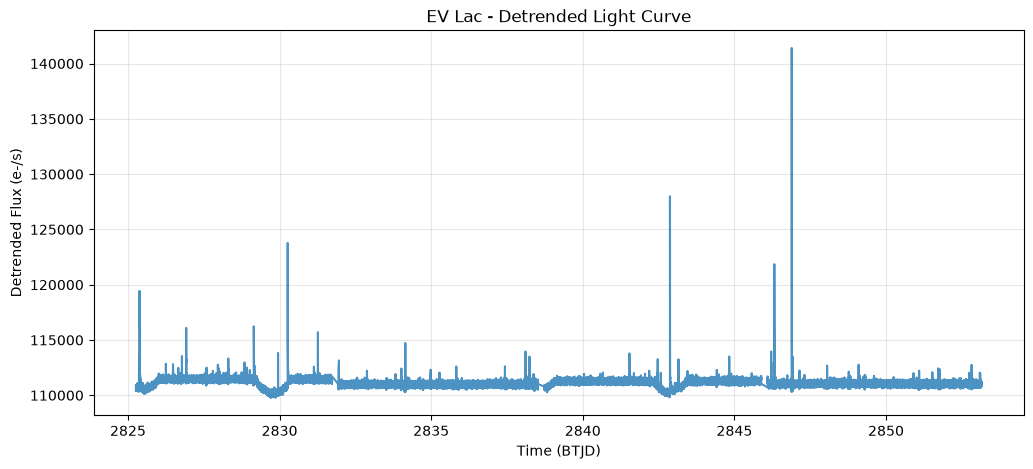

In [145]:
plt.figure(figsize=(12,5))
plt.plot(clean_detrended_lc.time.value,clean_detrended_lc.detrended_flux, alpha=0.8)
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux (e-/s)")
plt.title(f"{target_name} - Detrended Light Curve")
plt.grid(True, alpha =0.3)
plt.show()

### Modifying detrending window

In [146]:
clean_detrended_24= clean_flare_lc.detrend("savgol", window_length=4321)
clean_detrended_12= clean_flare_lc.detrend("savgol", window_length=2161)

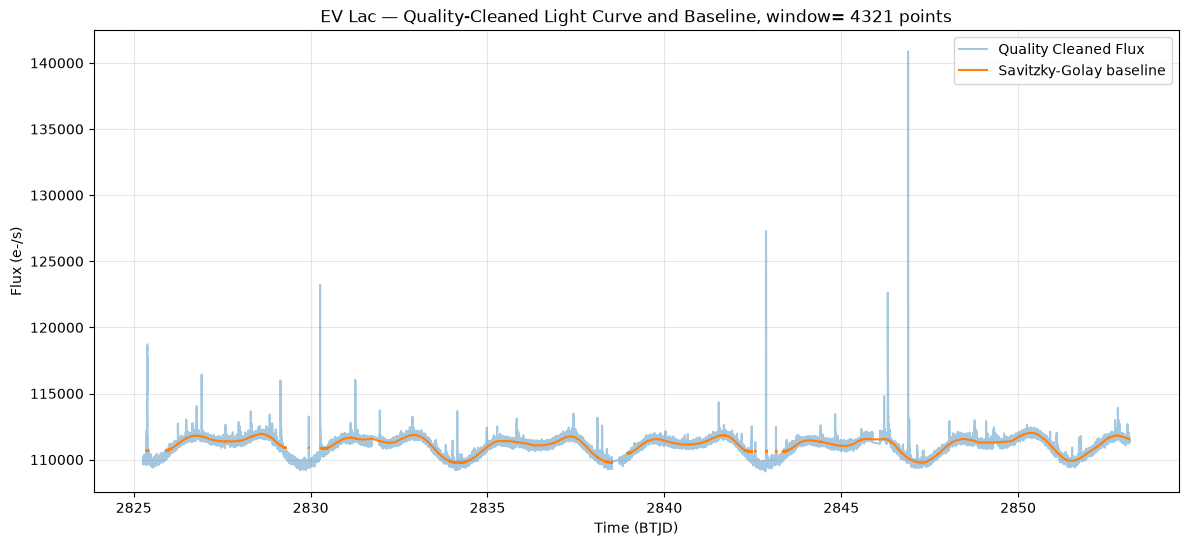

In [212]:
plt.figure(figsize=(14,6))
plt.plot(clean_flare_lc.time.value,clean_flare_lc.flux, alpha=0.4,label="Quality Cleaned Flux")
plt.plot(clean_detrended_lc.time.value,clean_detrended_24.flux_model,alpha=1, label="Savitzky-Golay baseline")
plt.xlabel("Time (BTJD)")
plt.ylabel("Flux (e-/s)")
plt.title(f"{target_name} — Quality-Cleaned Light Curve and Baseline, window= 4321 points")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

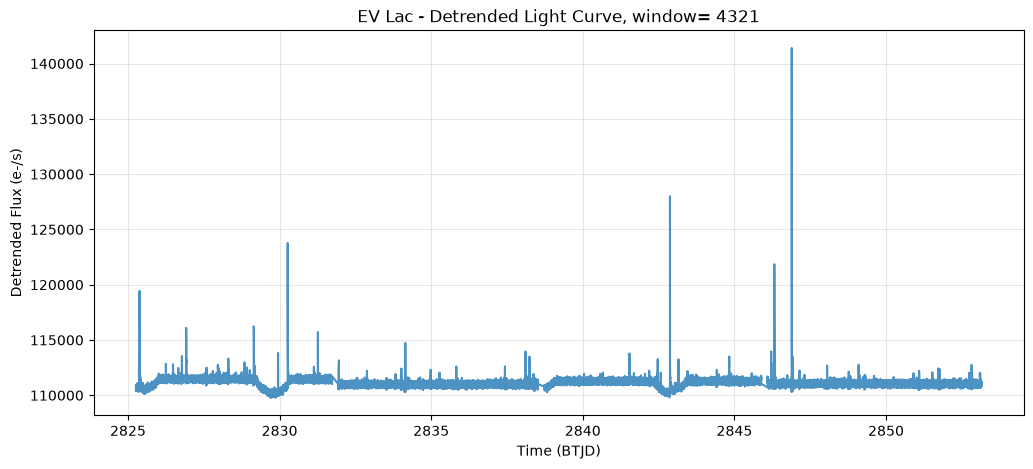

In [148]:
plt.figure(figsize=(12,5))
plt.plot(clean_detrended_lc.time.value,clean_detrended_lc.detrended_flux, alpha=0.8)
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux (e-/s)")
plt.title(f"{target_name} - Detrended Light Curve, window= 4321")
plt.grid(True, alpha =0.3)
plt.show()

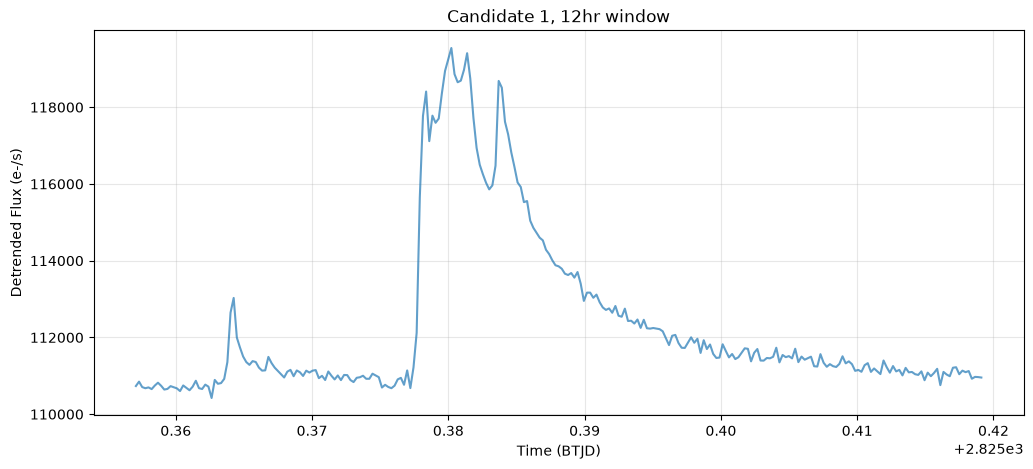

In [149]:
candidate= flare_table.iloc[1]
t_start=candidate["tstart"]
t_stop=candidate["tstop"]
window= (30/(24*60))

mask=((clean_detrended_12.time.value >= t_start-window) & (clean_detrended_12.time.value<= t_stop+window))

plt.figure(figsize=(12,5))
plt.plot(clean_detrended_12.time.value[mask], clean_detrended_12.detrended_flux[mask], alpha=0.7, label="12-hour window")
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux (e-/s)")
plt.title("Candidate 1, 12hr window")
plt.grid(True, alpha =0.3)
plt.show()

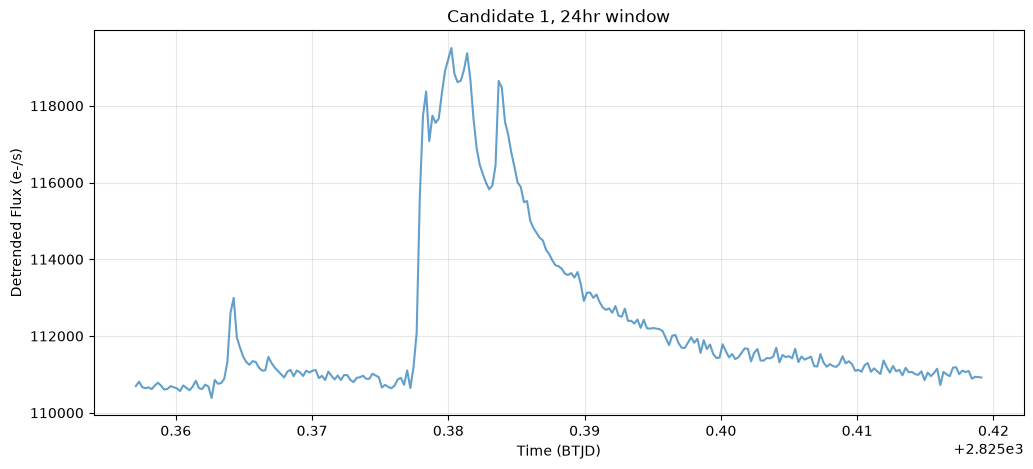

In [150]:
mask=((clean_detrended_24.time.value >= t_start-window) & (clean_detrended_24.time.value<= t_stop+window))

plt.figure(figsize=(12,5))
plt.plot(clean_detrended_24.time.value[mask], clean_detrended_24.detrended_flux[mask], alpha=0.7, label="24-hour window")
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux (e-/s)")
plt.title("Candidate 1, 24hr window")
plt.grid(True, alpha =0.3)
plt.show()

### Checking for viable combination

In [151]:
clean_detrended_flares=clean_detrended_lc.find_flares()
clean_detrended_flares_12=clean_detrended_12.find_flares()
clean_detrended_flares_24=clean_detrended_24.find_flares()

Found 34 candidate(s) in the (0,26955) gap.
Found 29 candidate(s) in the (26955,54306) gap.
Found 31 candidate(s) in the (54306,84132) gap.
Found 41 candidate(s) in the (84132,113531) gap.
/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)
Found 61 candidate(s) in the (0,26955) gap.
Found 46 candidate(s) in the (26955,54306) gap.
Found 47 candidate(s) in the (54306,84132) gap.
Found 85 candidate(s) in the (84132,113531) gap.
/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In

In [152]:
clean_flare_table=clean_detrended_flares.meta["flares"]
clean_flare_table_12=clean_detrended_flares_12.meta["flares"]
clean_flare_table_24=clean_detrended_flares_24.meta["flares"]

In [153]:
print("2.4hr:", len(clean_flare_table))
print("12hr:", len(clean_flare_table_12))
print("24hr:", len(clean_flare_table_24))

2.4hr: 135
12hr: 239
24hr: 293


In [154]:
print("2.4 hr:")
print(clean_flare_table[["tstart","tstop"]].head())
print("\n12 hr:")
print(clean_flare_table_12[["tstart","tstop"]].head())
print("\n24 hr:")
print(clean_flare_table_24[["tstart","tstop"]].head())

2.4 hr:
        tstart        tstop
0  2825.364015  2825.364710
1  2825.377673  2825.398507
2  2826.248531  2826.255475
3  2826.485111  2826.487889
4  2826.549696  2826.550391

12 hr:
        tstart        tstop
0  2825.364015  2825.364941
1  2825.377673  2825.399433
2  2826.248531  2826.257790
3  2826.484880  2826.487889
4  2826.549696  2826.550391

24 hr:
        tstart        tstop
0  2825.364015  2825.364941
1  2825.377673  2825.398507
2  2826.248531  2826.257790
3  2826.337654  2826.338579
4  2826.484880  2826.487889


In [155]:
def interval_overlap(row_a,row_b):
    return(row_a["tstart"] <= row_b["tstop"] and row_b["tstart"] <= row_a["tstop"])

def count_matches(table_a,table_b):
    matches=0
    for _,flare_a in table_a.iterrows():
        for _,flare_b in table_b.iterrows():
            if interval_overlap(flare_a,flare_b):
                matches += 1
                break
    return matches

print("No: 12h cadence overlap with 2.4h:", count_matches(clean_flare_table_12, clean_flare_table))
print("No: 24h cadence overlap with 2.4h:", count_matches(clean_flare_table_24, clean_flare_table))


No: 12h cadence overlap with 2.4h: 117
No: 24h cadence overlap with 2.4h: 117


In [156]:
def find_unmatched (table_a,table_b):
    unmatched=[]
    for i, flare_a in table_a.iterrows():
        matched= False
        for _,flare_b in table_b.iterrows():
            if interval_overlap(flare_a,flare_b):
                matched= True
                break
        if not matched:
            unmatched.append(i)
    return unmatched

unmatched_12=find_unmatched(clean_flare_table_12, clean_flare_table)
unmatched_24=find_unmatched(clean_flare_table_24, clean_flare_table)

print("No: of unmatched 12h flares:", len(unmatched_12))
print("No: of unmatched 24h flares:", len(unmatched_24))

print("\nFirst 10 unmatched flares in 12hr:")
print(clean_flare_table_12.loc[unmatched_12[:20],["tstart","tstop","ed_rec","ampl_rec","dur"]])

print("\nFirst 10 unmatched flares in 24hr:")
print(clean_flare_table_24.loc[unmatched_24[:20],["tstart","tstop","ed_rec","ampl_rec","dur"]])



No: of unmatched 12h flares: 122
No: of unmatched 24h flares: 176

First 10 unmatched flares in 12hr:
         tstart        tstop               ed_rec      ampl_rec       dur
7   2826.765211  2826.765906  0.16036695589968275  0.0029195547  0.000694
8   2826.767989  2826.768915  0.30096604606258737  0.0044893026  0.000926
11  2826.932345  2826.933503   0.3121958144230881  0.0045917034  0.001157
15  2827.608288  2827.611066   0.7931122145132363  0.0047529936  0.002778
16  2827.613613  2827.614307  0.20526209373296211  0.0043945312  0.000694
17  2827.619863  2827.622872   0.7712986878861656   0.004505992  0.003009
18  2827.627039  2827.627965  0.21377148641074228  0.0028607845  0.000926
25  2828.241406  2828.242100  0.15019066701689354  0.0027685165  0.000694
27  2828.318260  2828.318954  0.17601202346428124  0.0034199953  0.000694
33  2828.862949  2828.863643  0.19619452574431762   0.003759265  0.000694
34  2828.865495  2828.866421   0.2688805348591963  0.0043239594  0.000926
35  2828.8

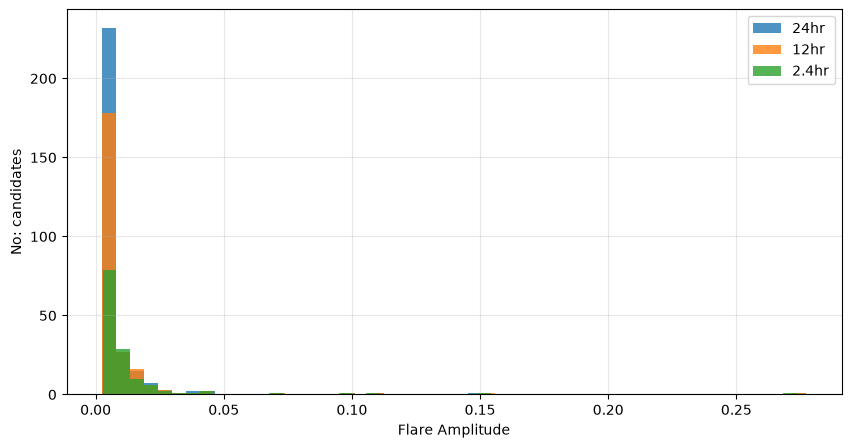

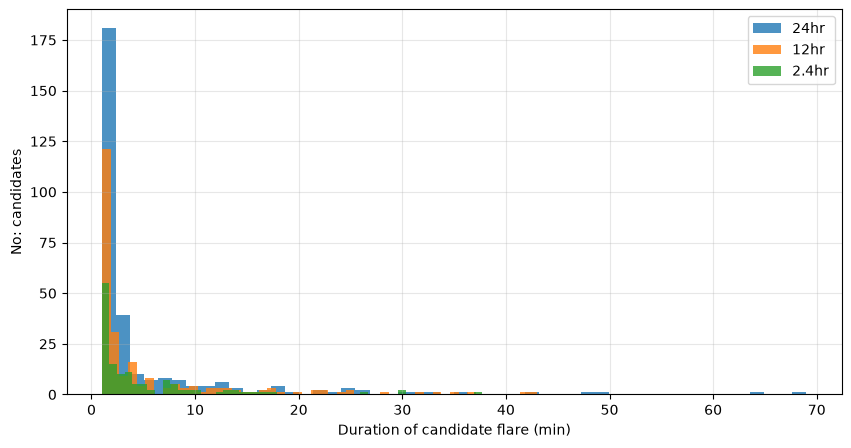

In [157]:
plt.figure (figsize=(10,5))
plt.hist(clean_flare_table_24["ampl_rec"], bins=50, alpha =0.8, label="24hr")
plt.hist(clean_flare_table_12["ampl_rec"], bins=50, alpha =0.8, label="12hr")
plt.hist(clean_flare_table["ampl_rec"], bins=50, alpha =0.8, label="2.4hr")

plt.xlabel("Flare Amplitude")
plt.ylabel("No: candidates")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


plt.figure (figsize=(10,5))
plt.hist(clean_flare_table_24["dur"]*24*60, bins=50, alpha =0.8, label="24hr")
plt.hist(clean_flare_table_12["dur"]*24*60, bins=50, alpha =0.8, label="12hr")
plt.hist(clean_flare_table["dur"]*24*60, bins=50, alpha =0.8, label="2.4hr")

plt.xlabel("Duration of candidate flare (min)")
plt.ylabel("No: candidates")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


In [158]:
flare_24_n3=clean_detrended_24.find_flares(N3=3)
flare_24_n4=clean_detrended_24.find_flares(N3=4)
flare_24_n5=clean_detrended_24.find_flares(N3=5)

table_n3=flare_24_n3.meta["flares"]
table_n4=flare_24_n4.meta["flares"]
table_n5=flare_24_n5.meta["flares"]

print("\nN3=3:", len(table_n3))
print("N3=4:", len(table_n4))
print("N3=5:", len(table_n5))


print("\nN3=3 -> N3=4:",len(table_n3)-len(table_n4))
print("N3=4 -> N3=5:",len(table_n4)-len(table_n5))

Found 70 candidate(s) in the (0,26955) gap.
Found 61 candidate(s) in the (26955,54306) gap.
Found 61 candidate(s) in the (54306,84132) gap.
Found 101 candidate(s) in the (84132,113531) gap.
/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)
Found 49 candidate(s) in the (0,26955) gap.
Found 40 candidate(s) in the (26955,54306) gap.
Found 31 candidate(s) in the (54306,84132) gap.
Found 76 candidate(s) in the (84132,113531) gap.
/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. I


N3=3: 293
N3=4: 196
N3=5: 138

N3=3 -> N3=4: 97
N3=4 -> N3=5: 58


/Users/alanjohn/flare_project/lib/python3.12/site-packages/altaipony/altai.py:210: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lc.flares = pd.concat([lc.flares, new], ignore_index=True)


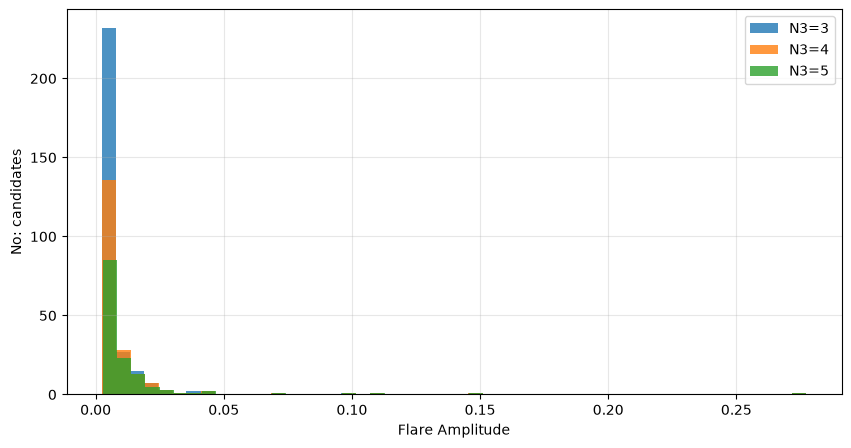

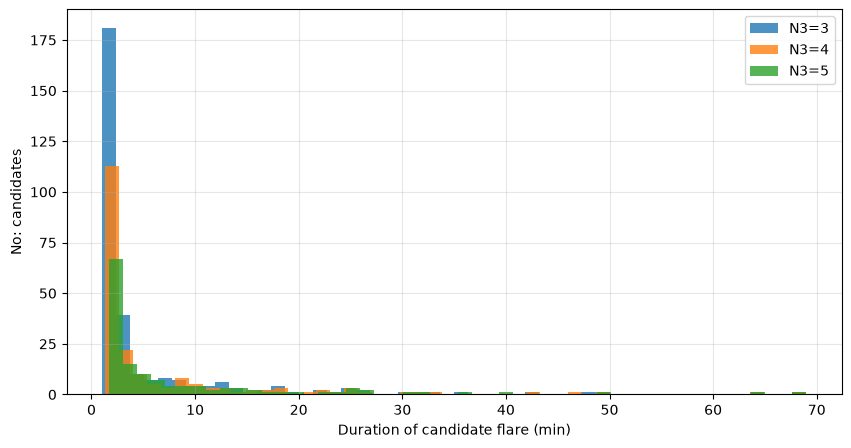

In [159]:
plt.figure (figsize=(10,5))
plt.hist(table_n3["ampl_rec"], bins=50, alpha =0.8, label="N3=3")
plt.hist(table_n4["ampl_rec"], bins=50, alpha =0.8, label="N3=4")
plt.hist(table_n5["ampl_rec"], bins=50, alpha =0.8, label="N3=5")

plt.xlabel("Flare Amplitude")
plt.ylabel("No: candidates")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


plt.figure (figsize=(10,5))
plt.hist(table_n3["dur"]*24*60, bins=50, alpha =0.8, label="N3=3")
plt.hist(table_n4["dur"]*24*60, bins=50, alpha =0.8, label="N3=4")
plt.hist(table_n5["dur"]*24*60, bins=50, alpha =0.8, label="N3=5")

plt.xlabel("Duration of candidate flare (min)")
plt.ylabel("No: candidates")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


In [160]:
print("N3=3:",((table_n3["tstart"]<= 2825.39851)&(table_n3["tstop"]>= 2825.3777)).sum())
print("N3=4:",((table_n4["tstart"]<= 2825.39851)&(table_n4["tstop"]>= 2825.3777)).sum())
print("N3=5:",((table_n5["tstart"]<= 2825.39851)&(table_n5["tstop"]>= 2825.3777)).sum())

N3=3: 1
N3=4: 1
N3=5: 1


In [161]:
print("N3=3 Durations")
print(np.sort(table_n3["dur"].values *24*60)[:20])
print("N3=4 Durations")
print(np.sort(table_n4["dur"].values *24*60)[:20])
print("N3=5 Durations")
print(np.sort(table_n5["dur"].values *24*60)[:20])

N3=3 Durations
[0.99999954 1.00000021 1.00000021 1.00000088 1.00000155 1.00000155
 1.00000222 1.00000222 1.00000222 1.00000222 1.00000356 1.00000356
 1.00000356 1.00000356 1.00000356 1.00000423 1.00000457 1.00000457
 1.00000457 1.00000457]
N3=4 Durations
[1.33333272 1.33333272 1.33333339 1.33333339 1.33333339 1.33333339
 1.33333473 1.33333473 1.3333354  1.33333674 1.33333674 1.33333741
 1.33333741 1.33333741 1.33333808 1.33333841 1.33333942 1.33333942
 1.33333942 1.33333942]
N3=5 Durations
[1.66666523 1.6666659  1.66666858 1.66667059 1.66667394 1.66667428
 1.66667428 1.66667428 1.66667495 1.66667864 1.66667897 1.66669373
 1.66669406 1.66669506 1.66669741 1.66669842 1.66669842 1.66670177
 1.66670814 1.66670847]


# Difference Method

In [162]:
flux=np.array(clean_detrended_24.detrended_flux)
difference= np.diff(flux)

print("The no: Fluxes:", len(flux))
print("The no: differemces:", len(difference))
print("The First 10 differences:")
print(difference[:10])

The no: Fluxes: 113531
The no: differemces: 113530
The First 10 differences:
[ 282.42188    16.273438  -42.640625  -39.351562 -140.67969    -5.671875
  430.79688  -251.82031   -45.570312  240.22656 ]


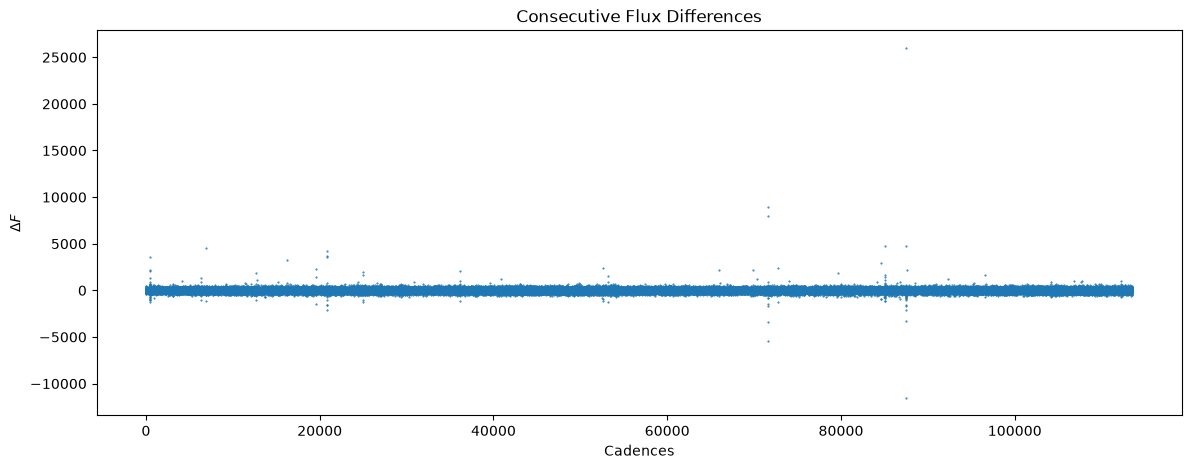

In [163]:
plt.figure(figsize=(14,5))
plt.plot(difference,".",markersize=1)
plt.xlabel("Cadences")
plt.ylabel(r"$\Delta F$")
plt.title("Consecutive Flux Differences")
plt.show()

In [164]:
print("Mean difference:", np.mean(difference))
print("Standard Deviation of difference:", np.std(difference))

print("\nMedian of difference:",np.median(difference))
print("Median Absolute Deviation:", np.median(np.abs(difference-np.median(difference))))

Mean difference: 0.0034117496
Standard Deviation of difference: 206.9977

Median of difference: -0.859375
Median Absolute Deviation: 118.859375


In [165]:
time=clean_detrended_24.time.value *24*60*60
dt=np.diff(time)

print("Median Cadence:", np.median(dt),"s")
print("Minimum Cadence:", np.min(dt),"s")
print("Maximum Cadence:", np.max(dt),"s")

print("\n10 Largest time gap:",np.sort(dt)[-10:])

Median Cadence: 20.000312596559525 s
Minimum Cadence: 19.99995043873787 s
Maximum Cadence: 18560.292226284742 s

10 Largest time gap: [   60.00172246    80.00016415    80.00024471    80.00062692
    80.00068721    80.00080785    80.00185391 18260.08637208
 18500.38185269 18560.29222628]


In [166]:
time= clean_detrended_24.time.value
flux=np.array(clean_detrended_24.detrended_flux)

dt=np.diff(time)*24*60*60
valid=(dt>19.5)&(dt<20.5)

difference=np.diff(flux)[valid]

print("Total possible differences:", len(dt))
print("Valid 20s differences:", len(difference))
print("Rejected differences:", np.sum(~valid))

Total possible differences: 113530
Valid 20s differences: 109508
Rejected differences: 4022


In [167]:
print("Mean difference:", np.mean(difference))
print("Standard Deviation of difference:", np.std(difference))

print("\nMedian of difference:",np.median(difference))
print("Median Absolute Deviation:", np.median(np.abs(difference-np.median(difference))))

Mean difference: -0.3683807
Standard Deviation of difference: 205.85645

Median of difference: -0.92578125
Median Absolute Deviation: 118.85547


In [168]:
diff_time=time[1:][valid]
print("No: Differences:",len(difference))
print("No: of Difference Times:", len(diff_time))

print("\nFirst 5:")
print("Time:",diff_time[:5])
print("Difference:",difference[:5])

No: Differences: 109508
No: of Difference Times: 109508

First 5:
Time: [2825.26100309 2825.26123458 2825.26146606 2825.26169755 2825.26192904]
Difference: [ 282.42188    16.273438  -42.640625  -39.351562 -140.67969 ]


In [169]:
sigma=np.std(difference)

mad=np.median(np.abs(difference-np.median(difference)))
sigma_robust=1.4826*mad

threshold_std= 3*sigma
threshold_robust= 3*sigma_robust
print("3\u03c3 threshold ordinary:", threshold_std)
print("3\u03c3 robust threshold:", threshold_robust)

print("\nPositive difference above ordinary 3\u03c3:", np.sum(difference>threshold_std))
print("\nPositive difference above robust 3\u03c3:", np.sum(difference>threshold_robust))

3σ threshold ordinary: 617.56934
3σ robust threshold: 528.6454

Positive difference above ordinary 3σ: 94

Positive difference above robust 3σ: 242


### Ordinary vs Robust Threshold

In [170]:
significant=difference>threshold_std
sig_times= diff_time[significant]
sig_diffrences= difference[significant]

print("Significant Positive differencs:", len(sig_times))
print("\nFirst 20:")
for t,d in zip(sig_times[:20],sig_diffrences[:20]):
    print(f"{t:.6f}     {d:.2f}")

Significant Positive differencs: 94

First 20:
2825.364015     1288.42
2825.377673     900.45
2825.377905     3530.95
2825.378136     2119.00
2825.378368     637.62
2825.378831     664.08
2825.379525     658.34
2825.383692     2208.92
2826.015423     681.94
2826.248762     951.76
2826.778869     944.99
2826.779100     1274.06
2827.477730     628.62
2827.998807     839.49
2828.029595     656.77
2828.154598     698.65
2828.305991     661.47
2828.308306     1877.05
2828.545117     621.20
2828.915496     863.95


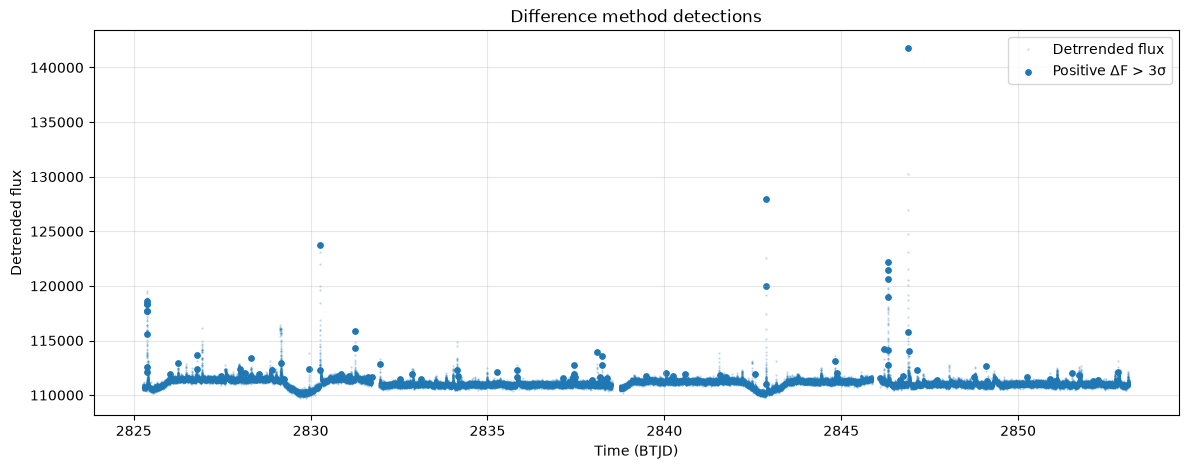

In [171]:
plt.figure(figsize=(14,5))
plt.plot(time,flux,".",markersize=1,alpha=0.3,label="Detrrended flux")

plt.scatter(sig_times,flux[1:][valid][significant],s=15,label="Positive \u0394F > 3\u03c3")

plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended flux")
plt.title("Difference method detections")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [172]:
sig_dt=np.diff(sig_times)*24*60
print("First 20 seperations(min):")
print(sig_dt[:20])

First 20 seperations(min):
[1.96672332e+01 3.33342902e-01 3.33342902e-01 3.33342902e-01
 6.66685805e-01 1.00002871e+00 6.00017291e+00 9.09692216e+02
 3.36009157e+02 7.63353663e+02 3.33341897e-01 1.00602591e+03
 7.50352081e+02 4.43344266e+01 1.80004422e+02 2.18005321e+02
 3.33341427e+00 3.41008246e+02 5.33346050e+02 3.62675191e+02]


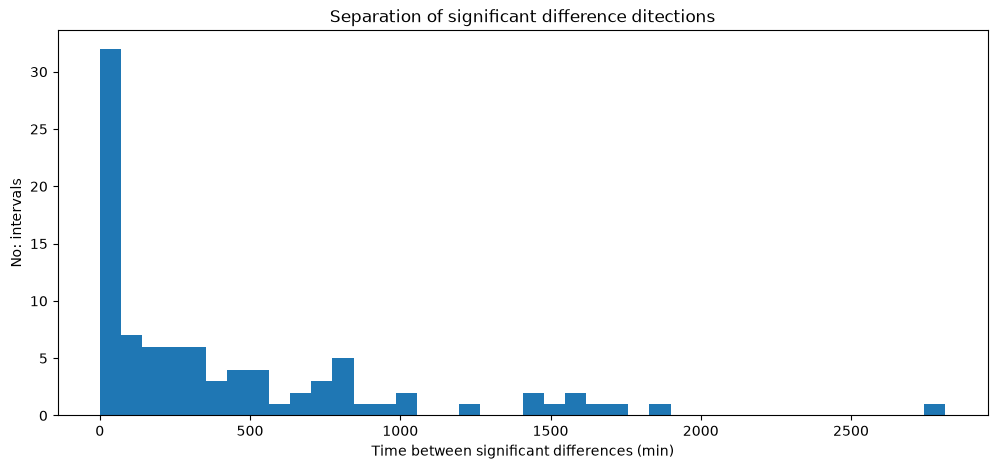

In [173]:
plt.figure(figsize=(12,5))
plt.hist(sig_dt,bins=40)
plt.xlabel("Time between significant differences (min)")
plt.ylabel("No: intervals")
plt.title("Separation of significant difference ditections")
plt.show()

In [174]:
flare= clean_flare_table_24.iloc[1]
t_start= flare["tstart"]
t_stop= flare["tstop"]

padding=2/(24*60) #2min in days

mask=(sig_times>=t_start-padding)&(sig_times<=t_stop+padding)

print("Candidate:",1)
print("Start:",t_start)
print("Stop:",t_stop)
print("Signifcant difference points:",np.sum(mask))
print("\nTime:")
print(sig_times[mask])

Candidate: 1
Start: 2825.377673129541
Stop: 2825.3985070620975
Signifcant difference points: 7

Time:
[2825.37767313 2825.37790462 2825.37813611 2825.37836759 2825.37883057
 2825.37952503 2825.38369182]


In [175]:
difference_support=[]
for _, flare in clean_flare_table_24.iterrows():
    t_start= flare["tstart"]
    t_stop= flare["tstop"]
    mask=(sig_times>=t_start-padding)&(sig_times<=t_stop+padding)

    difference_support.append(np.sum(mask))

difference_support=np.array(difference_support)

print("Number of AliaiPony candidates:",len(clean_flare_table_24))
print("Candidates with difference support:",np.sum(difference_support>0))
print("Condidates without difference support:",np.sum(difference_support==0))

Number of AliaiPony candidates: 293
Candidates with difference support: 39
Condidates without difference support: 254


In [176]:
print("Ordinary 3\u03c3 support counts:")
print("0 points:",np.sum(difference_support==0))
print("1 point:",np.sum(difference_support==1))
print("2 points:",np.sum(difference_support==2))
print("3 points:",np.sum(difference_support==3))
print("4+ points:",np.sum(difference_support>=4))

Ordinary 3σ support counts:
0 points: 254
1 point: 29
2 points: 7
3 points: 1
4+ points: 2


In [177]:
support_idx=np.where(difference_support>=2)[0]
print("number of candidates with >=2 support point:", len(support_idx))
print("\nCandidate | Support Points | Amplitude | Duration (min)")
for idx in support_idx:
    flare=clean_flare_table_24.iloc[idx]
    print(idx, "|",difference_support[idx],"|", flare["ampl_rec"],"|",flare["dur"]*24*60 )

number of candidates with >=2 support point: 10

Candidate | Support Points | Amplitude | Duration (min)
1 | 7 | 0.07249308 | 30.0008628811338
10 | 2 | 0.020457625 | 12.00031464206404
48 | 2 | 0.110785484 | 26.333917954325443
57 | 2 | 0.04010439 | 22.667147034517257
104 | 2 | 0.0163517 | 9.666832519505988
122 | 2 | 0.016062856 | 13.33355113689322
128 | 2 | 0.023719668 | 13.000208903686143
156 | 3 | 0.14982462 | 13.000107986226794
217 | 6 | 0.10066223 | 49.3335485838179
221 | 2 | 0.2773255 | 31.666785810375586


# Profile validation

In [178]:
profile_result=[]
for idx in support_idx:
    flare=clean_flare_table_24.iloc[idx]
    t_start= flare["tstart"]
    t_stop= flare["tstop"]
    mask=(clean_detrended_24.time.value>=t_start)&(clean_detrended_24.time.value<=t_stop)
    flare_flux=clean_detrended_24.detrended_flux[mask]
    flare_time=clean_detrended_24.time.value[mask]

    peak_idx=np.nanargmax(flare_flux)
    t_peak=flare_time[peak_idx]

    rise_time=(t_peak-t_start)*24*60
    decay_time=(t_stop-t_peak)*24*60

    profile_result.append([idx, difference_support[idx],flare["ampl_rec"],flare["dur"]*24*60,rise_time,decay_time])
print("Candidate | Support | Amplitude | Duration | Rise | Decay")
for row in profile_result:
    print(f"{int(row[0]):9d} |",f"{int(row[1]):7d} |", f"{row[2]:9.4f} |", f"{row[3]:8.2f} |", f"{row[4]:3.2f} |", f"{row[5]:6.2f}")

Candidate | Support | Amplitude | Duration | Rise | Decay
        1 |       7 |    0.0725 |    30.00 | 3.67 |  26.33
       10 |       2 |    0.0205 |    12.00 | 2.67 |   9.33
       48 |       2 |    0.1108 |    26.33 | 1.67 |  24.67
       57 |       2 |    0.0401 |    22.67 | 1.00 |  21.67
      104 |       2 |    0.0164 |     9.67 | 1.00 |   8.67
      122 |       2 |    0.0161 |    13.33 | 0.67 |  12.67
      128 |       2 |    0.0237 |    13.00 | 0.33 |  12.67
      156 |       3 |    0.1498 |    13.00 | 0.33 |  12.67
      217 |       6 |    0.1007 |    49.33 | 2.33 |  47.00
      221 |       2 |    0.2773 |    31.67 | 0.33 |  31.33


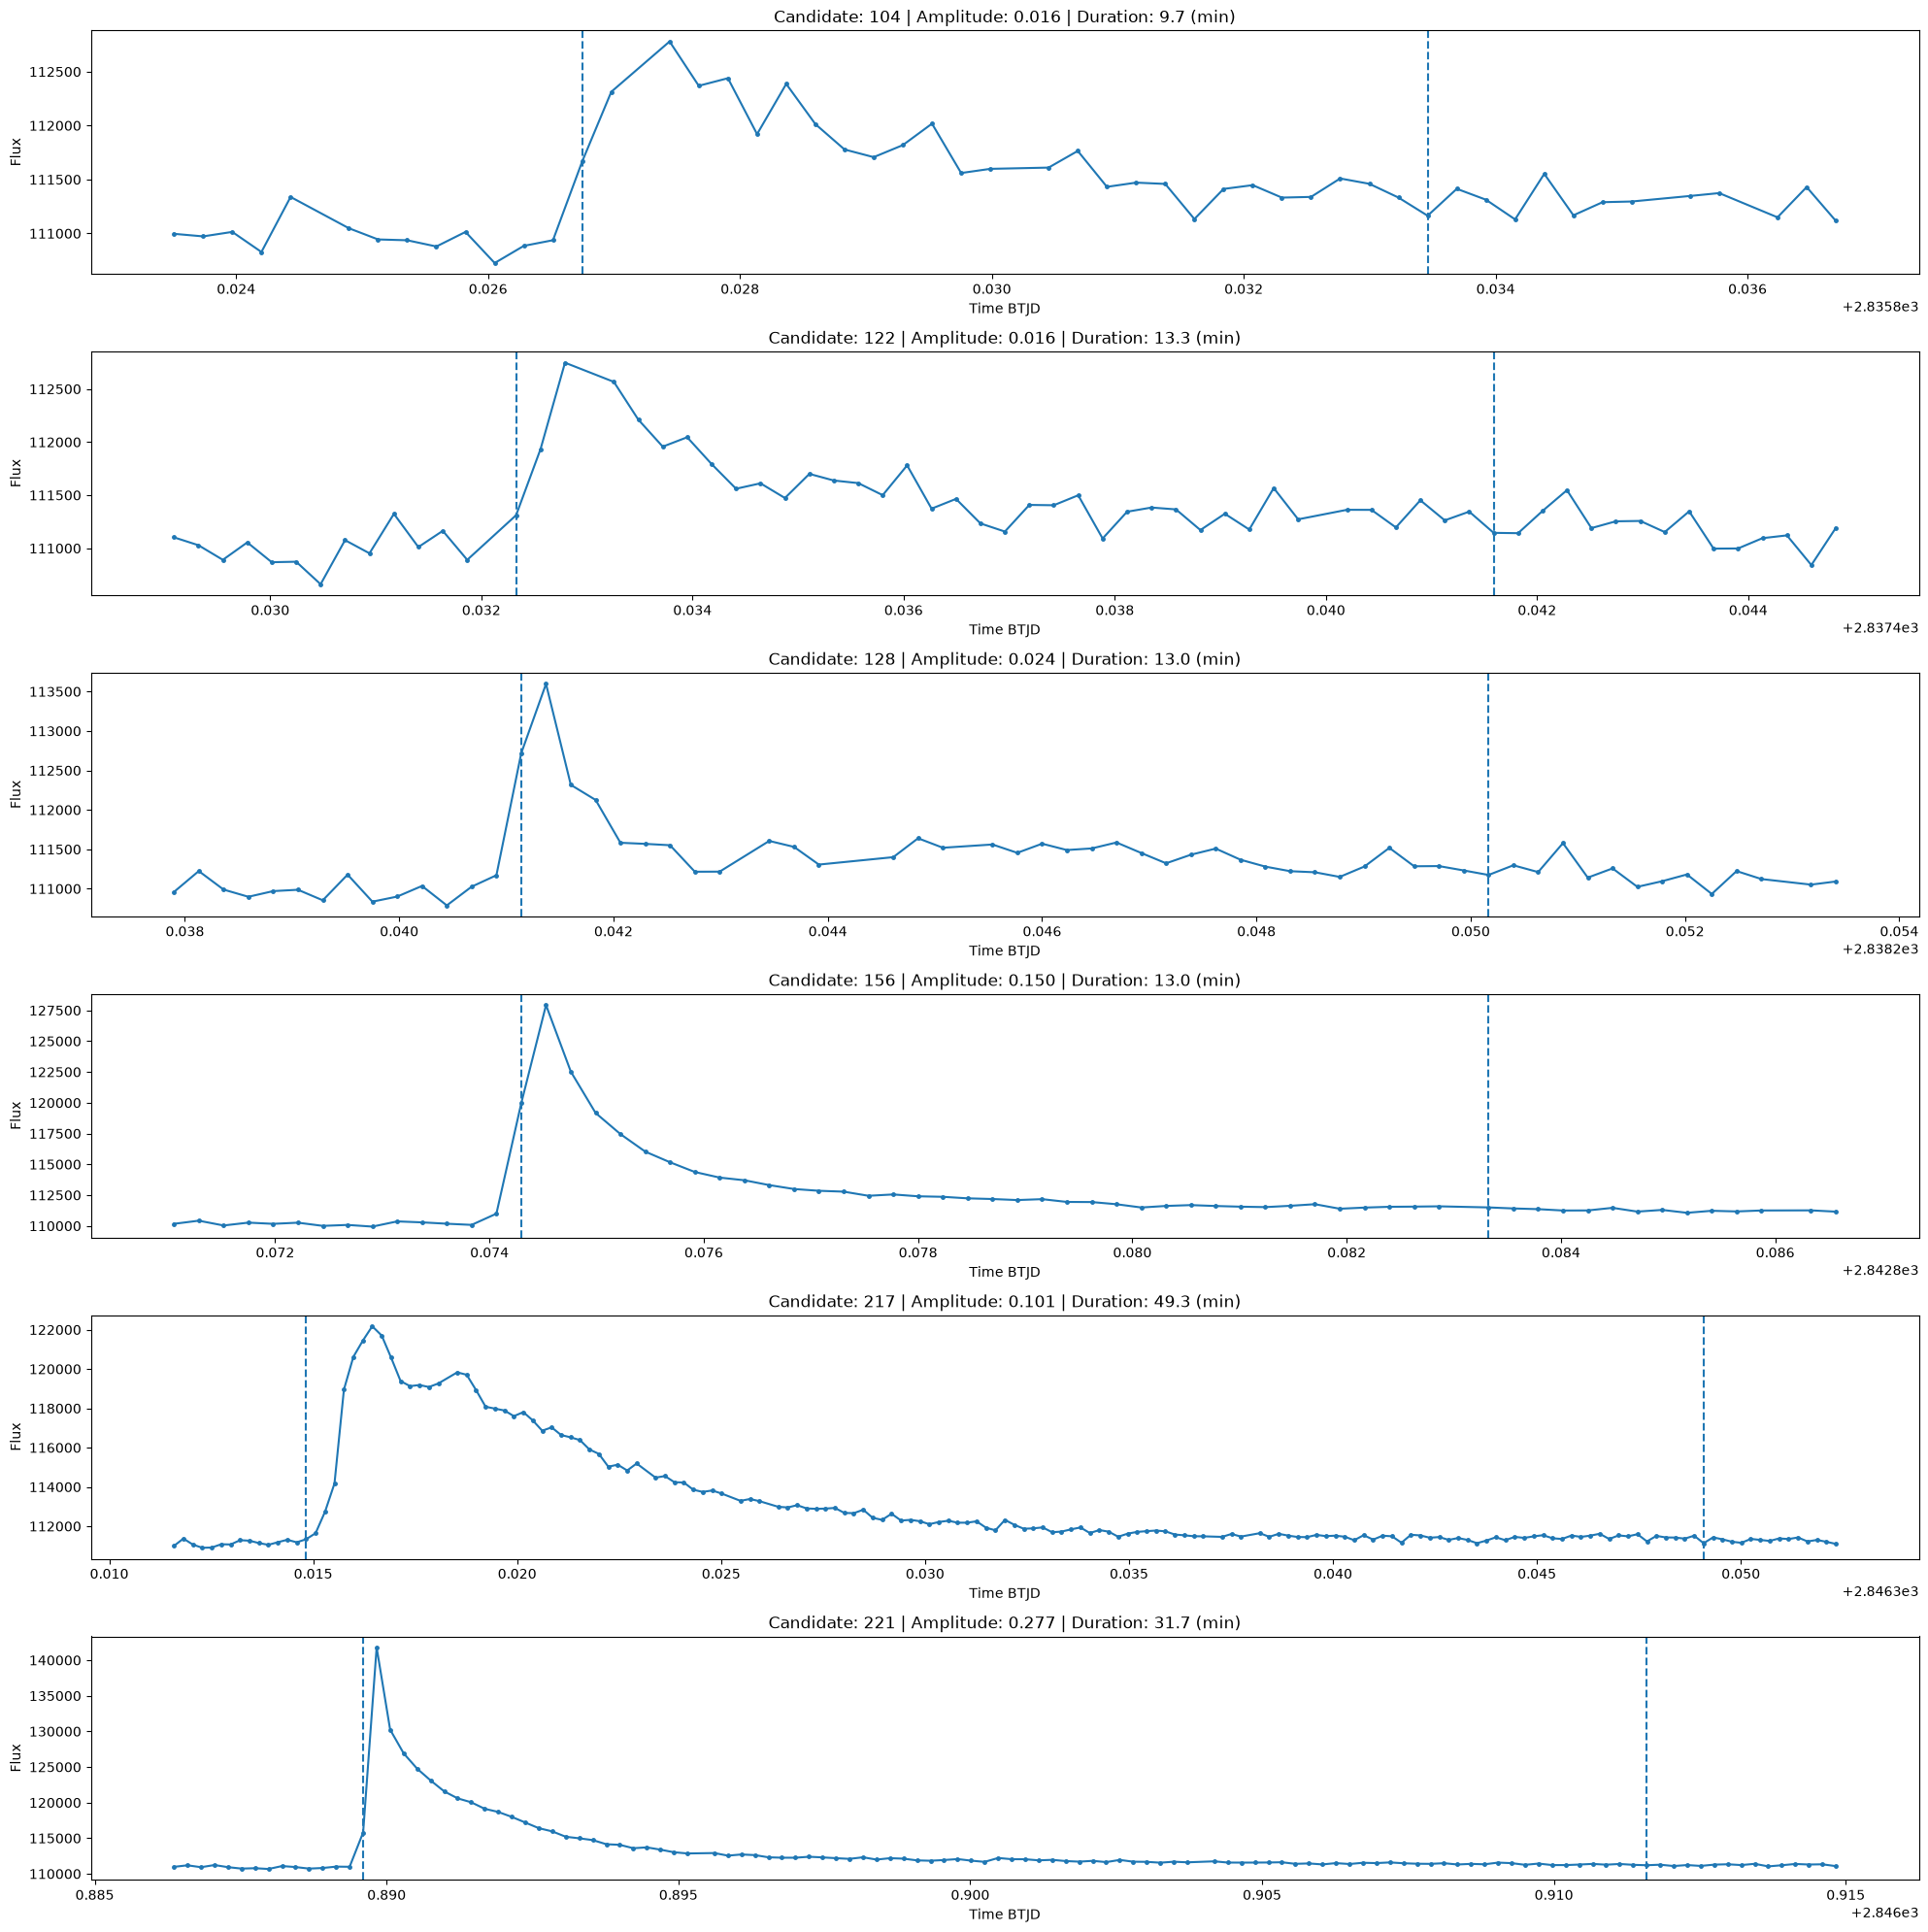

In [179]:
candidates_to_plot=[104,122,128,156,217,221]
fig,axes=plt.subplots(6,1,figsize=(20,20))
for ax, idx in zip(axes, candidates_to_plot):
    flare=clean_flare_table_24.iloc[idx]

    t_start= flare["tstart"]
    t_stop= flare["tstop"]
    padding=5/(24*60) #2min in days
    mask=(clean_detrended_24.time.value>=t_start-padding)&(clean_detrended_24.time.value<=t_stop+padding)

    ax.plot(clean_detrended_24.time.value[mask], clean_detrended_24.detrended_flux[mask],".-",markersize=5
            )

    ax.axvline(t_start,linestyle="--")
    ax.axvline(t_stop,linestyle="--")

    ax.set_title(f"Candidate: {idx} | "
                 f"Amplitude: {flare["ampl_rec"]:.3f} | "
                 f"Duration: {flare["dur"]*24*60:.1f} (min)")
    
    ax.set_xlabel("Time BTJD")   
    ax.set_ylabel("Flux")
plt.tight_layout()
plt.show() 

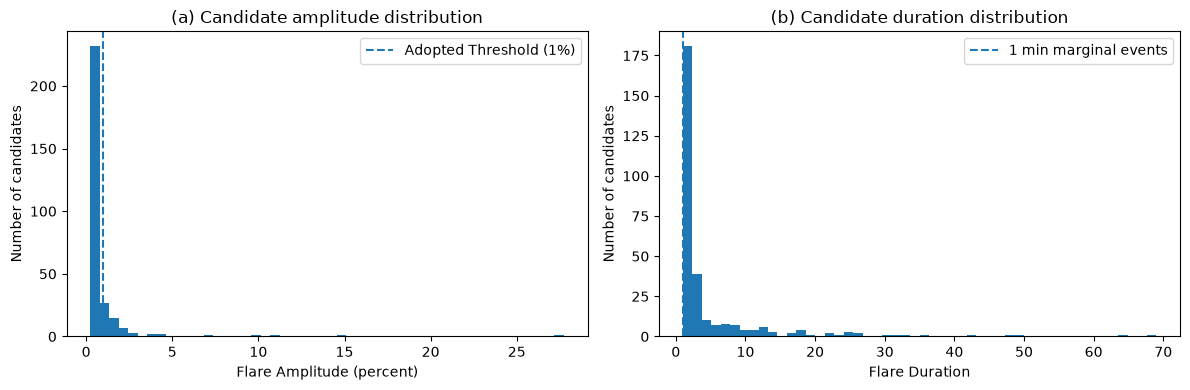

In [235]:
amplitude=clean_flare_table_24["ampl_rec"]*100
duration=clean_flare_table_24["dur"]*24*60

fig, axes= plt.subplots(1,2,figsize=(12,4))

axes[0].hist(amplitude, bins=50)
axes[0].axvline(1, linestyle="--", label="Adopted Threshold (1%)")
axes[0].set_xlabel("Flare Amplitude (percent)")
axes[0].set_ylabel("Number of candidates")
axes[0].legend()
axes[0].set_title("(a) Candidate amplitude distribution")

axes[1].hist(duration, bins=50)
axes[1].axvline(1, linestyle="--", label="1 min marginal events")
axes[1].set_xlabel("Flare Duration")
axes[1].set_ylabel("Number of candidates")
axes[1].legend()
axes[1].set_title("(b) Candidate duration distribution")
plt.tight_layout()
plt.show()

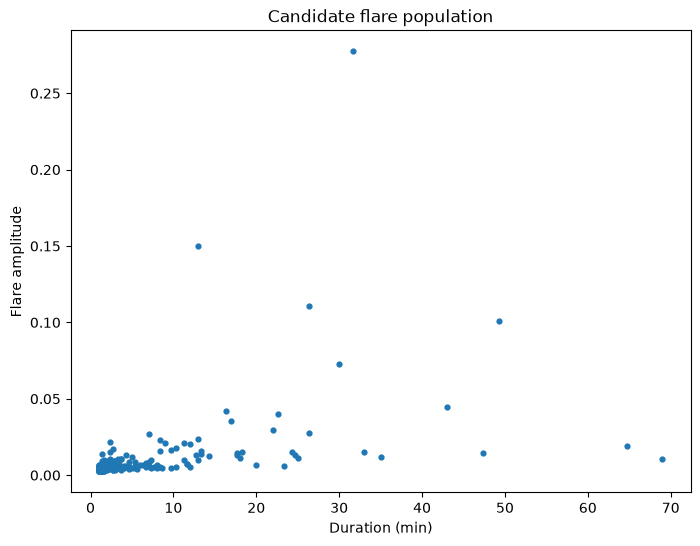

In [181]:
plt.figure(figsize=(8,6))
plt.scatter(duration,amplitude,s=12)
plt.xlabel("Duration (min)")
plt.ylabel("Flare amplitude")
plt.title("Candidate flare population")
plt.show()

In [182]:
for threshold in [0.002,0.005,0.01,0.015,0.02,0.03,0.05]:
    n=np.sum(amplitude>=threshold)
    print(f"Amplitude >={threshold:.3f}: {n} candidates")

for threshold in [1,2,3,5,10]:
    n=np.sum(duration>=threshold)
    print(f"Duration >={threshold:.3f}(min): {n} candidates")


Amplitude >=0.002: 293 candidates
Amplitude >=0.005: 126 candidates
Amplitude >=0.010: 47 candidates
Amplitude >=0.015: 26 candidates
Amplitude >=0.020: 18 candidates
Amplitude >=0.030: 9 candidates
Amplitude >=0.050: 5 candidates
Duration >=1.000(min): 292 candidates
Duration >=2.000(min): 132 candidates
Duration >=3.000(min): 100 candidates
Duration >=5.000(min): 65 candidates
Duration >=10.000(min): 39 candidates


In [183]:
amp= clean_flare_table_24["ampl_rec"].values
duration=clean_flare_table_24["dur"]*24*60

mask_1pct= amp>=0.01

print("Candidates with amplitude >=1%: ",np.sum(mask_1pct))
print("Candidates with amplitude <1%: ",np.sum(~mask_1pct))

print("\nDuration distribution of amplitude >=1%:")
for threshold in [1,2,3,5,10]:
    n=np.sum((mask_1pct) &(duration>=threshold))
    print(f"Amplitude >=1% and duration >= {threshold} min: {n}")

Candidates with amplitude >=1%:  47
Candidates with amplitude <1%:  246

Duration distribution of amplitude >=1%:
Amplitude >=1% and duration >= 1 min: 47
Amplitude >=1% and duration >= 2 min: 46
Amplitude >=1% and duration >= 3 min: 42
Amplitude >=1% and duration >= 5 min: 38
Amplitude >=1% and duration >= 10 min: 31


In [184]:
for threshold in [0.005,0.01,0.015,0.02]:
    mask=amplitude>=threshold
    print(f"\nAmplitude >={threshold:.3f}: {np.sum(mask)} candidates")
    print(f"with >=1 differnce points: {np.sum(mask & (difference_support>=1))}")
    print(f"with >=2 differnce points: {np.sum(mask & (difference_support>=2))}")




Amplitude >=0.005: 126 candidates
with >=1 differnce points: 39
with >=2 differnce points: 10

Amplitude >=0.010: 47 candidates
with >=1 differnce points: 29
with >=2 differnce points: 10

Amplitude >=0.015: 26 candidates
with >=1 differnce points: 20
with >=2 differnce points: 10

Amplitude >=0.020: 18 candidates
with >=1 differnce points: 16
with >=2 differnce points: 8


# Final Pipeline

In [185]:
working_lc=clean_detrended_24
working_flares=clean_detrended_flares_24
working_flare_table=clean_flare_table_24

normalised_flux=(working_lc.detrended_flux/ np.nanmean(working_lc.detrended_flux))
relative_time= working_lc.time.value - 2825



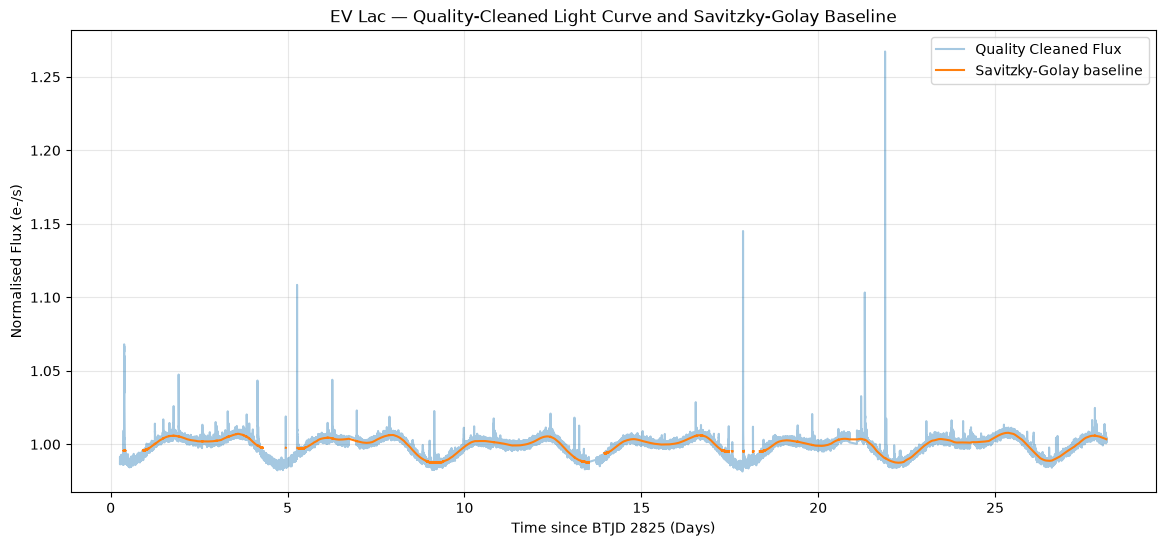

In [223]:
nf1=(clean_flare_lc.flux/ np.nanmean(clean_detrended_24.flux_model))
rt1= clean_flare_lc.time.value - 2825

nf2=(clean_detrended_24.flux_model/ np.nanmean(clean_detrended_24.flux_model))

plt.figure(figsize=(14,6))
plt.plot(rt1,nf1, alpha=0.4,label="Quality Cleaned Flux")
plt.plot(rt1,nf2,alpha=1, label="Savitzky-Golay baseline")
plt.xlabel("Time since BTJD 2825 (Days)")
plt.ylabel("Normalised Flux (e-/s)")
plt.title(f"{target_name} — Quality-Cleaned Light Curve and Savitzky-Golay Baseline")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

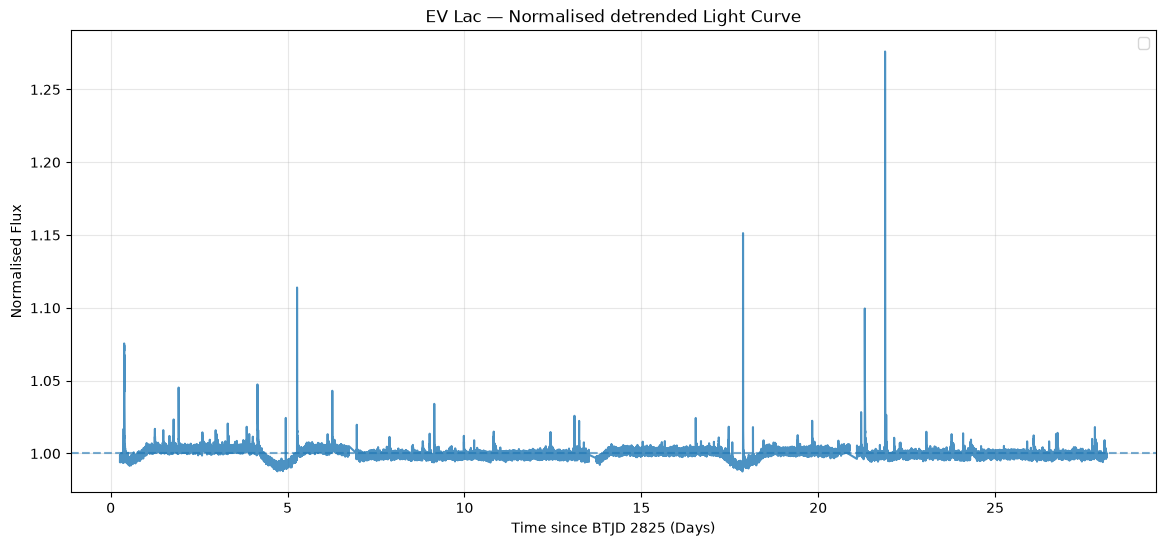

In [186]:
plt.figure(figsize=(14,6))
plt.plot(relative_time, normalised_flux, alpha=0.8,)
plt.xlabel("Time since BTJD 2825 (Days)")
plt.ylabel("Normalised Flux")
plt.title(f"{target_name} — Normalised detrended Light Curve")
plt.axhline(1, linestyle="--", alpha=0.6)
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [187]:
print(working_flares.colnames)
print(working_flares)

['time', 'flux', 'flux_err', 'detrended_flux', 'flux_model', 'detrended_flux_err', 'it_med', 'cadenceno']
       time             flux         flux_err    ...   it_med   cadenceno
                    electron / s   electron / s  ...                     
------------------ -------------- -------------- ... ---------- ---------
 2825.260771600005  1.0971659e+05  8.2818680e+01 ... 111428.234       nan
2825.2610030881315  1.0999902e+05  8.2976456e+01 ... 111428.234       nan
 2825.261234576491  1.1001529e+05  8.2961807e+01 ... 111428.234       nan
2825.2614660646177  1.0997265e+05  8.2961601e+01 ... 111428.234       nan
2825.2616975527435  1.0993330e+05  8.2941856e+01 ... 111428.234       nan
 2825.261929041103  1.0979262e+05  8.2916656e+01 ... 111428.234       nan
2825.2621605292297  1.0978695e+05  8.2895958e+01 ... 111428.234       nan
2825.2623920175893  1.1021774e+05  8.2965042e+01 ... 111428.234       nan
 2825.262623505715  1.0996592e+05  8.2942085e+01 ... 111428.234       nan
      

In [188]:
print(working_flares.meta)

{'gaps': [(np.int64(0), np.int64(26955)), (np.int64(26955), np.int64(54306)), (np.int64(54306), np.int64(84132)), (np.int64(84132), np.int64(113531))], 'flares':      istart   istop  cstart  cstop       tstart        tstop  \
0       426     430     NaN    NaN  2825.364015  2825.364941   
1       483     571     NaN    NaN  2825.377673  2825.398507   
2      4114    4152     NaN    NaN  2826.248531  2826.257790   
3      4483    4486     NaN    NaN  2826.337654  2826.338579   
4      5095    5108     NaN    NaN  2826.484880  2826.487889   
..      ...     ...     ...    ...          ...          ...   
288  112186  112373     NaN    NaN  2852.821086  2852.865994   
289  112388  112391     NaN    NaN  2852.869466  2852.870160   
290  113322  113343     NaN    NaN  2853.092845  2853.097938   
291  113347  113352     NaN    NaN  2853.098864  2853.100021   
292  113370  113374     NaN    NaN  2853.104188  2853.105345   

                  ed_rec            ed_rec_err      ampl_rec       du

In [189]:
print(working_flare_table.columns)
print("Number of flares:", len(working_flare_table))

Index(['istart', 'istop', 'cstart', 'cstop', 'tstart', 'tstop', 'ed_rec',
       'ed_rec_err', 'ampl_rec', 'dur', 'total_n_valid_data_points'],
      dtype='object')
Number of flares: 293


In [190]:
print(working_flare_table[["tstart","tstop","ed_rec","ampl_rec","dur"]].head(10))

        tstart        tstop               ed_rec      ampl_rec       dur
0  2825.364015  2825.364941   0.6368703519975583   0.014035225  0.000926
1  2825.377673  2825.398507    51.99336837324741    0.07249308  0.020834
2  2826.248531  2826.257790     5.25773906598269   0.014029264  0.009260
3  2826.337654  2826.338579   0.3165615663663601   0.004534483  0.000926
4  2826.484880  2826.487889   1.8884018506660425   0.013134241  0.003009
5  2826.549696  2826.550391  0.20728903044852487  0.0038599968  0.000694
6  2826.658727  2826.660810   0.9423814035113587   0.009174228  0.002083
7  2826.759887  2826.764285   1.4728813414909432   0.006483555  0.004398
8  2826.765211  2826.765906   0.1717374376727534  0.0031075478  0.000694
9  2826.767989  2826.768915   0.3174626596464982   0.004693866  0.000926


### Amplitude Threshold

In [191]:
amp_mask=working_flare_table["ampl_rec"]>=0.01
working_flare_table= working_flare_table.loc[amp_mask].copy()
print("Candidate catalogue:", len(working_flare_table))

Candidate catalogue: 47


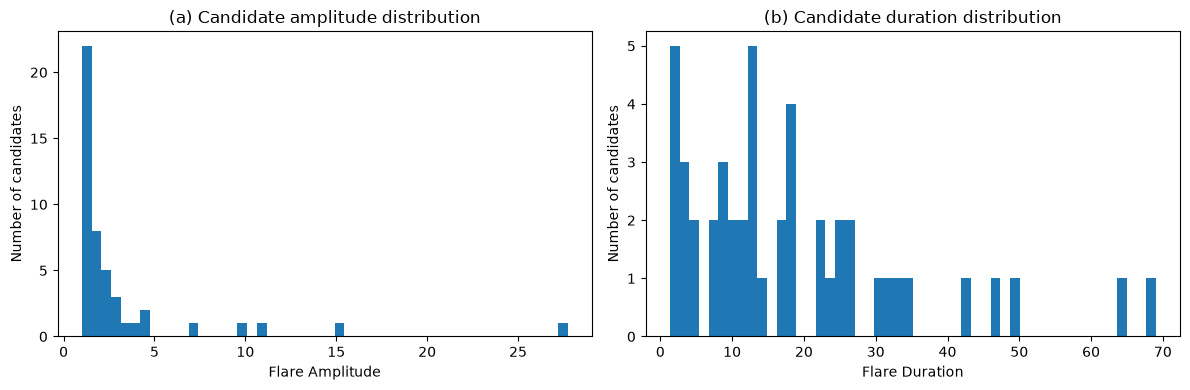

In [ ]:
amplitude=working_flare_table["ampl_rec"]
duration=working_flare_table["dur"]*24*60

fig, axes= plt.subplots(1,2,figsize=(12,4))

axes[0].hist(amplitude, bins=50)
axes[0].set_xlabel("Flare Amplitude")
axes[0].set_ylabel("Number of candidates")
axes[0].set_title("(a) Candidate amplitude distribution")

axes[1].hist(duration, bins=50)
axes[1].set_xlabel("Flare Duration")
axes[1].set_ylabel("Number of candidates")
axes[1].set_title("(b) Candidate duration distribution")
plt.tight_layout()
plt.show()

### Difference Method Support

In [192]:
support_counts=[]
padding=2/(24*60)
for _,flare in working_flare_table.iterrows():
    t_start=flare["tstart"]
    t_stop=flare["tstop"]

    mask=(sig_times>=t_start-padding)&(sig_times<=t_stop+padding)

    support_counts.append(np.sum(mask))
working_flare_table["difference_support"]= support_counts
print(working_flare_table[["ampl_rec", "dur", "difference_support"]].head(10))

       ampl_rec       dur  difference_support
0   0.014035225  0.000926                   1
1    0.07249308  0.020834                   7
2   0.014029264  0.009260                   1
4   0.013134241  0.003009                   0
10  0.020457625  0.008334                   2
11   0.04228735  0.011343                   0
16  0.011616111  0.024306                   0
25  0.013066411  0.012269                   0
27  0.010311365  0.002315                   1
29  0.017641664  0.007176                   1


In [193]:
print(working_flare_table["difference_support"].value_counts().sort_index())

difference_support
0    18
1    19
2     7
3     1
6     1
7     1
Name: count, dtype: int64


### Profile Validation

In [194]:
profile_result=[]

time=working_lc.time.value
flux=np.array(working_lc.detrended_flux)

for idx, flare in working_flare_table.iterrows():
    t_start=flare["tstart"]
    t_stop=flare["tstop"]

    mask=(time>=t_start)&(time<=t_stop)

    flare_time=time[mask]
    flare_flux=flux[mask]

    peak_index=np.nanargmax(flare_flux)
    t_peak=flare_time[peak_index]

    rise_time=(t_peak-t_start)*24*60
    decay_time=(t_stop-t_peak)*24*60

    profile_result.append({"candidate":idx, "rise_time_min":rise_time, "decay_time_min":decay_time, "rise_lt_decay" :rise_time<decay_time, "two_rise_lt_decay":2*rise_time<=decay_time})
profile_table=pd.DataFrame(profile_result)
profile_table.head()

,candidate,rise_time_min,decay_time_min,rise_lt_decay,two_rise_lt_decay
0,0,0.333343,1.000029,True,True
1,1,3.666772,26.334091,True,True
2,2,1.333370,12.000324,True,True
3,4,1.333369,3.000080,True,True
4,10,2.666737,9.333578,True,True


In [195]:
working_flare_table_profile = working_flare_table.merge(profile_table,left_index=True, right_on="candidate", how="left")

In [196]:
print("Total Candidates:", len(working_flare_table))
print("rise < decay:", working_flare_table_profile["rise_lt_decay"].sum())
print("2*rise < decay:", working_flare_table_profile["two_rise_lt_decay"].sum())

Total Candidates: 47
rise < decay: 47
2*rise < decay: 44


In [197]:
working_flare_table_profile[["ampl_rec","difference_support", "rise_time_min","decay_time_min", "rise_lt_decay", "two_rise_lt_decay"]].head(10)

,ampl_rec,difference_support,rise_time_min,decay_time_min,rise_lt_decay,two_rise_lt_decay
0,0.014035225,1,0.333343,1.000029,True,True
1,0.07249308,7,3.666772,26.334091,True,True
2,0.014029264,1,1.333370,12.000324,True,True
3,0.013134241,0,1.333369,3.000080,True,True
4,0.020457625,2,2.666737,9.333578,True,True
5,0.04228735,0,0.000000,16.333758,True,True
6,0.011616111,0,2.666734,32.334147,True,True
7,0.013066411,0,4.666782,13.000321,True,True
8,0.010311365,1,0.666683,2.666732,True,True
9,0.017641664,1,0.000000,10.333585,True,True


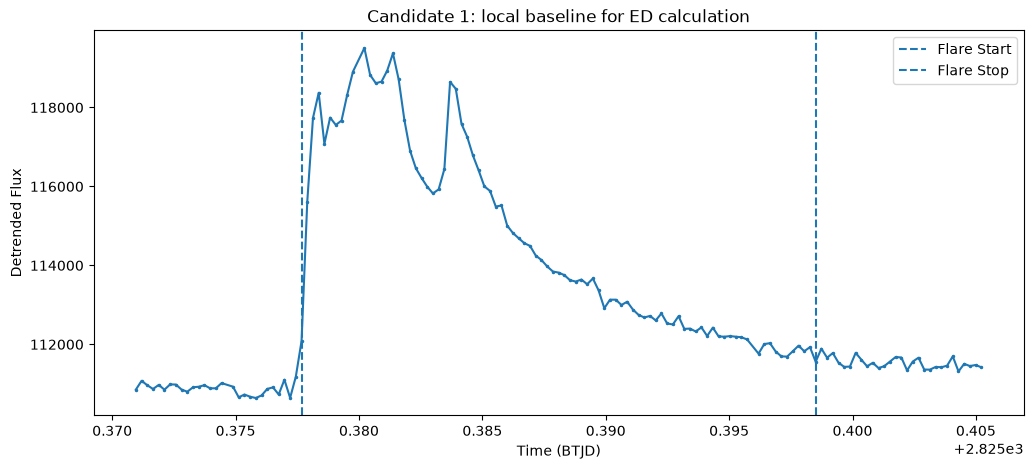

In [198]:
candidate= 1
flare= working_flare_table_profile[working_flare_table_profile["candidate"]==candidate].iloc[0]

t_start=flare["tstart"]
t_stop=flare["tstop"]

padding=10/(24*60)

time=working_lc.time.value
flux=np.array(working_lc.detrended_flux)

mask=(time>=t_start-padding)&(time<=t_stop+padding)

plt.figure(figsize=(12,5))
plt.plot(time[mask],flux[mask],".-", markersize=3)
plt.axvline(t_start,linestyle="--",label="Flare Start")
plt.axvline(t_stop,linestyle="--",label="Flare Stop")
plt.xlabel("Time (BTJD)")
plt.ylabel("Detrended Flux")
plt.title(f"Candidate {flare["candidate"]}: local baseline for ED calculation")
plt.legend()
plt.show()

In [199]:
working_flare_table_profile[["candidate", "ampl_rec", "dur", "ed_rec", "ed_rec_err", "difference_support", "rise_time_min", "decay_time_min"]].head(10)

,candidate,ampl_rec,dur,ed_rec,ed_rec_err,difference_support,rise_time_min,decay_time_min
0,0,0.014035225,0.000926,0.6368703519975583,0.025995876625535493,1,0.333343,1.000029
1,1,0.07249308,0.020834,51.99336837324741,0.11772344641110154,7,3.666772,26.334091
2,2,0.014029264,0.009260,5.25773906598269,0.08901542962695237,1,1.333370,12.000324
3,4,0.013134241,0.003009,1.8884018506660425,0.05008869816418644,0,1.333369,3.000080
4,10,0.020457625,0.008334,3.999922171824444,0.07424712941155974,2,2.666737,9.333578
5,11,0.04228735,0.011343,13.184861742472101,0.08720284911680944,0,0.000000,16.333758
6,16,0.011616111,0.024306,10.637031228012372,0.14587715526015765,0,2.666734,32.334147
7,25,0.013066411,0.012269,8.432410598649714,0.10435894398947398,0,4.666782,13.000321
8,27,0.010311365,0.002315,1.3630988877758732,0.0452399609970798,1,0.666683,2.666732
9,29,0.017641664,0.007176,3.7393120904430113,0.07955240649396814,1,0.000000,10.333585


### Flare Energy Calculation

In [200]:
working_flare_table_profile["ed_rec"]=working_flare_table_profile["ed_rec"].apply(lambda x:float(x))
working_flare_table_profile["ed_rec_err"]=working_flare_table_profile["ed_rec_err"].apply(lambda x:float(x))

In [201]:
print(working_flare_table_profile["ed_rec"].dtype)
print(type(working_flare_table_profile["ed_rec"].iloc[0]))
print(repr(working_flare_table_profile["ed_rec"].iloc[0]))

print("\n",working_flare_table_profile["ed_rec_err"].dtype)
print(type(working_flare_table_profile["ed_rec_err"].iloc[0]))
print(repr(working_flare_table_profile["ed_rec_err"].iloc[0]))

float64
<class 'numpy.float64'>
np.float64(0.6368703519975583)

 float64
<class 'numpy.float64'>
np.float64(0.025995876625535493)


In [202]:
print(working_flare_table_profile[["ed_rec","ed_rec_err"]].describe())

          ed_rec  ed_rec_err
count  47.000000   47.000000
mean   10.725883    0.090808
std    13.750310    0.041370
min     0.636870    0.025996
25%     3.441921    0.061058
50%     5.361003    0.087801
75%    10.950964    0.111041
max    63.350596    0.217385


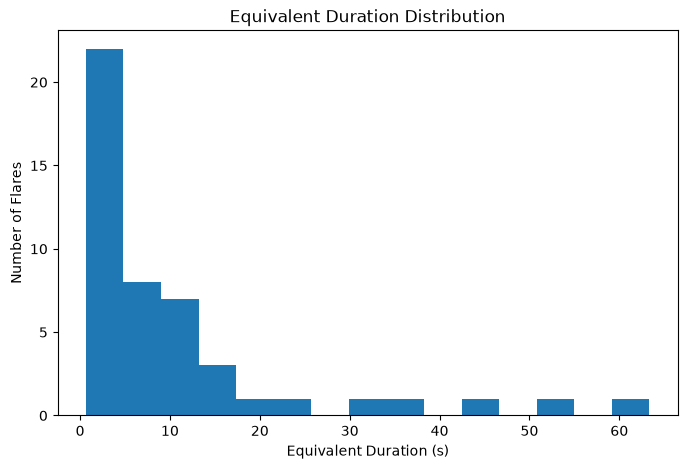

In [203]:
plt.figure(figsize=(8,5))
plt.hist(working_flare_table_profile["ed_rec"],bins=15)
plt.xlabel("Equivalent Duration (s)")
plt.ylabel("Number of Flares")
plt.title("Equivalent Duration Distribution")
plt.show()

In [204]:
T_eff=float(lc.meta["TEFF"])
R_star=float(lc.meta["RADIUS"])

print("T_eff= ", T_eff,"K")
print("R_star= ",R_star,"R_sun")

T_eff=  3311.0 K
R_star=  0.33686599 R_sun


#### Calculating Luminosity

In [205]:
from astropy.constants import L_sun
T_sun= 5772 #K

L_star=((R_star**2)*((T_eff/T_sun)**4))*L_sun.cgs.value

print("L_star= ",L_star,"erg/s")

L_star=  4.703462610891497e+31 erg/s


In [206]:
working_flare_table_profile["flare_energy_erg"]=(working_flare_table_profile["ed_rec"]*L_star)
working_flare_table_profile["log_energy"]=(np.log10(working_flare_table_profile["flare_energy_erg"]))
working_flare_table_profile[["candidate","ed_rec","flare_energy_erg","log_energy"]].head(10)

,candidate,ed_rec,flare_energy_erg,log_energy
0,0,0.636870,2.995496e+31,31.476469
1,1,51.993368,2.445489e+33,33.388366
2,2,5.257739,2.472958e+32,32.393217
3,4,1.888402,8.882027e+31,31.948512
4,10,3.999922,1.881348e+32,32.274469
5,11,13.184862,6.201450e+32,32.792493
6,16,10.637031,5.003088e+32,32.699238
7,25,8.432411,3.966153e+32,32.598369
8,27,1.363099,6.411285e+31,31.806945
9,29,3.739312,1.758771e+32,32.245209


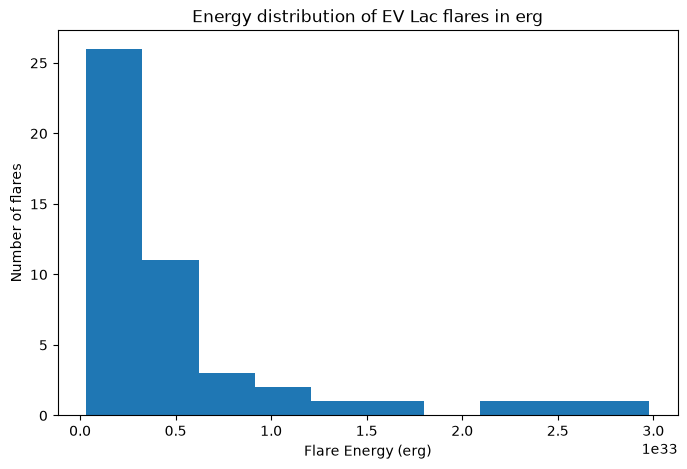

In [207]:
plt.figure(figsize=(8,5))
plt.hist(working_flare_table_profile["flare_energy_erg"],bins=10)
plt.xlabel("Flare Energy (erg)")
plt.ylabel("Number of flares")
plt.title(f"Energy distribution of {target_name} flares in erg")
plt.show()

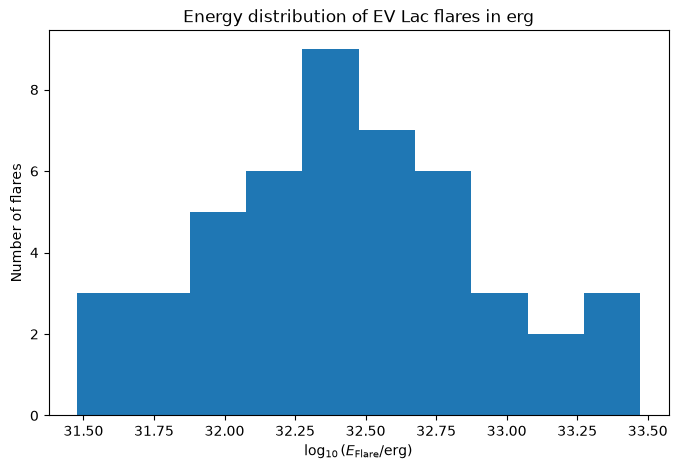

In [208]:
plt.figure(figsize=(8,5))
plt.hist(working_flare_table_profile["log_energy"],bins=10)
plt.xlabel(r"$\log_{10}(E_{\rm Flare}/{\rm erg})$")
plt.ylabel("Number of flares")
plt.title(f"Energy distribution of {target_name} flares in erg")
plt.show()

In [209]:
# final_table=working_flare_table_profile.copy()
# file_name=f"{target_name.replace(' ','_')}_Final_Flare_Catalogue.csv"
# final_table.to_csv(file_name, index=False)